# 9.10 Proyecto Integrador 
## Predicción de default en Lending Club

In [1]:
import itertools   
import time        
import warnings
from pathlib import Path   

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats   

try:
    import missingno as msno
    MSNO_OK = True
except Exception as exc:
    MSNO_OK = False
    print(f"[aviso] missingno no disponible ({exc}); se usa un heatmap propio como respaldo.")


warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid")         
pd.set_option("display.max_columns", 200)  
pd.set_option("display.max_rows", 20)

CLASS_LABELS = {0: "No Charged Off (0)", 1: "Charged Off (1)"}   # nombres legibles para gráficos y tablas
RANDOM_STATE = 42   # semilla fija: mismo resultado cada vez que se toma una muestra aleatoria

## 9.10.2. Dataset



In [2]:
DATA_SOURCE = "wordsforthewise/lending-club"

import kagglehub
dataset_path = kagglehub.dataset_download(DATA_SOURCE)
print("Dataset descargado en:", dataset_path)


csv_candidates = [p for p in Path(dataset_path).rglob("*.csv") if p.is_file() and "accepted" in p.name.lower()]
if not csv_candidates:
    raise FileNotFoundError("No se encontró un CSV 'accepted' dentro del dataset descargado.")
csv_path = csv_candidates[0]
print("Archivo usado:", csv_path)

c:\Users\juand\miniconda3\envs\ml_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset descargado en: C:\Users\juand\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3
Archivo usado: C:\Users\juand\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv


In [3]:
t0 = time.perf_counter()   # marca de tiempo antes de leer, para medir cuánto tarda pandas

df = pd.read_csv(csv_path, low_memory=False, dtype={"id": str})
t_pandas = time.perf_counter() - t0   # tiempo total de lectura con pandas
print(f"pandas: {len(df):,} filas x {df.shape[1]} columnas leídas en {t_pandas:,.1f} s")

pandas: 2,260,701 filas x 151 columnas leídas en 231.6 s


## 9.10.3. Target







In [4]:

df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

show_estados = df["loan_status"].value_counts(dropna=False)
show_estados_pct = 100 * show_estados / len(df)
display(pd.DataFrame({"registros": show_estados, "porcentaje": show_estados_pct,
                      "clase_default": [1 if e == "Charged Off" else 0 for e in show_estados.index]}))
print("Etiquetas usadas en todo el proyecto:", CLASS_LABELS)

print(f"\nAviso metodológico: bajo la fórmula literal del enunciado, todo estado distinto de "
      f"'Charged Off' (incluyendo préstamos 'Current', aún vigentes y sin resolver) queda como default=0. "
      f"Esto se deja documentado aquí y se retoma en el resumen ejecutivo (9.10.4.1.5).")

,registros,porcentaje,clase_default
loan_status,,,
Fully Paid,1076751,47.629076,0
Current,878317,38.851533,0
Charged Off,268559,11.879457,1
Late (31-120 days),21467,0.949573,0
In Grace Period,8436,0.373159,0
Late (16-30 days),4349,0.192374,0
Does not meet the credit policy. Status:Fully Paid,1988,0.087937,0
Does not meet the credit policy. Status:Charged Off,761,0.033662,0
Default,40,0.001769,0


Etiquetas usadas en todo el proyecto: {0: 'No Charged Off (0)', 1: 'Charged Off (1)'}

Aviso metodológico: bajo la fórmula literal del enunciado, todo estado distinto de 'Charged Off' (incluyendo préstamos 'Current', aún vigentes y sin resolver) queda como default=0. Esto se deja documentado aquí y se retoma en el resumen ejecutivo (9.10.4.1.5).


## 9.10.4.1. Exploración de datos (EDA)

### 9.10.4.1.1. Carga inicial y visión general

In [5]:
# 9.10.4.1.1 — Carga inicial y visión general: primeras y últimas filas, y dimensión del dataset.
display(df.head())
display(df.tail())
print(f"Dimensión del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,Vice President,9 years,MORTGAGE,227000.0,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,907xx,CA,12.75,7.0,Feb-1995,705.0,709.0,1.0,9.0,NaN,5.0,0.0,8633.0,64.9,37.0,f,23252.59,23252.59,24903.93,24903.93,16747.41,8156.52,0.00,0.0,0.0,Mar-2019,859.56,Apr-2019,Mar-2019,724.0,720.0,0.0,10.0,1.0,Individual,NaN,NaN,NaN,0.0,0.0,28398.0,0.0,2.0,0.0,1.0,15.0,19765.0,46.0,0.0,0.0,5141.0,51.0,13300.0,3.0,0.0,2.0,2.0,5680.0,4070.0,66.9,0.0,0.0,154.0,258.0,33.0,15.0,3.0,41.0,9.0,1.0,9.0,6.0,2.0,3.0,2.0,15.0,9.0,3.0,23.0,3.0,5.0,0.0,0.0,7.0,0.0,75.7,50.0,0.0,0.0,55970.0,28398.0,12300.0,42670.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,Program Manager,6 years,RENT,110000.0,Not Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,334xx,FL,18.30,0.0,Jul-1999,660.0,664.0,0.0,67.0,72.0,10.0,1.0,17641.0,68.1,31.0,f,0.00,0.00,6755.40,6755.40,3521.91,3233.49,0.00,0.0,0.0,Oct-2017,564.56,NaN,Mar-2019,594.0,590.0,0.0,67.0,1.0,Individual,NaN,NaN,NaN,0.0,0.0,62426.0,0.0,2.0,0.0,2.0,20.0,44785.0,78.0,1.0,5.0,6172.0,73.0,25900.0,0.0,0.0,1.0,7.0,6243.0,4660.0,77.5,0.0,0.0,132.0,206.0,9.0,9.0,2.0,9.0,NaN,9.0,NaN,1.0,5.0,7.0,5.0,15.0,4.0,8.0,24.0,7.0,10.0,0.0,0.0,0.0,1.0,96.2,40.0,1.0,0.0,84664.0,62426.0,

Dimensión del dataset: 2,260,701 filas x 152 columnas


In [6]:
df.info(verbose=True, show_counts=True, memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 152 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          2260701 non-null  object 
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  float64
 3    funded_amnt                                 2260668 non-null  float64
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  object 
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  object 
 9    sub_grade                                   

In [7]:
# describe() por separado para numéricas (media, std, min, percentiles, max) y para texto/categóricas
# (conteo, valores únicos, la más frecuente y su frecuencia). .T las transpone para que sea más legible
# cuando hay muchas columnas (una fila por variable en vez de una columna por variable).
display(df.describe(include="number").T)
display(df.describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,15046.931228,9190.245488,500.00,8000.00,12900.00,20000.0000,40000.00
funded_amnt,2260668.0,15041.664057,9188.413022,500.00,8000.00,12875.00,20000.0000,40000.00
funded_amnt_inv,2260668.0,15023.437745,9192.331679,0.00,8000.00,12800.00,20000.0000,40000.00
int_rate,2260668.0,13.092829,4.832138,5.31,9.49,12.62,15.9900,30.99
...,...,...,...,...,...,...,...,...
hardship_last_payment_amount,10917.0,193.994321,198.629496,0.01,44.44,133.16,284.1900,1407.86
settlement_amount,34246.0,5010.664267,3693.122590,44.21,2208.00,4146.11,6850.1725,33601.00
settlement_percentage,34246.0,47.780365,7.311822,0.20,45.00,45.00,50.0000,521.35
settlement_term,34246.0,13.191322,8.159980,0.00,6.00,14.00,18.0000,181.00


,count,unique,top,freq
id,2260701,2260701,68407277,1
term,2260668,2,36 months,1609754
grade,2260668,7,B,663557
sub_grade,2260668,35,C1,145903
emp_title,2093699,512694,Teacher,38824
...,...,...,...,...
disbursement_method,2260668,2,Cash,2182546
debt_settlement_flag,2260668,2,N,2226422
debt_settlement_flag_date,34246,83,Feb-2019,2606
settlement_status,34246,3,ACTIVE,14704


In [8]:
EXCLUIR_SIEMPRE = ["id", "member_id"]
for c in EXCLUIR_SIEMPRE:
    if c in df.columns:
        df[c] = df[c].astype(str)

if "id" in df.columns:
    print(f"'id' único: {df['id'].is_unique} | valores vacíos ('nan'): {(df['id'] == 'nan').sum():,}")


def emp_length_a_anios(s):
    """'< 1 year' -> 0.5 ; '1 year' -> 1 ; ... ; '10+ years' -> 10 ; faltante -> NaN."""
    s = s.astype("string").str.strip()
    anios = pd.to_numeric(s.str.extract(r"(\d+)", expand=False), errors="coerce").astype(float)
    anios = anios.mask(s.str.contains("<", regex=False, na=False), 0.5)
    return anios


df["emp_length_num"] = emp_length_a_anios(df["emp_length"])
display(df[["emp_length", "emp_length_num"]].drop_duplicates()
        .sort_values("emp_length_num", na_position="last").reset_index(drop=True))

numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ("default",) and c not in EXCLUIR_SIEMPRE]
categorical_cols = [c for c in df.select_dtypes(include=["object", "string"]).columns
                    if c not in ("loan_status",) and c not in EXCLUIR_SIEMPRE]

assert "emp_length_num" in numeric_cols and "emp_length" in categorical_cols
print(f"Numéricas: {len(numeric_cols)} | Categóricas: {len(categorical_cols)} "
      f"| Excluidas (id/member_id): {[c for c in EXCLUIR_SIEMPRE if c in df.columns]}")

'id' único: True | valores vacíos ('nan'): 0


,emp_length,emp_length_num
0,< 1 year,0.5
1,1 year,1.0
2,2 years,2.0
3,3 years,3.0
4,4 years,4.0
5,5 years,5.0
6,6 years,6.0
7,7 years,7.0
8,8 years,8.0
9,9 years,9.0


Numéricas: 113 | Categóricas: 36 | Excluidas (id/member_id): ['id', 'member_id']


### 9.10.4.1.2. Análisis unidimensional (por variable)

Se separan las columnas en numéricas y categóricas. `id` y `member_id` se excluyen del análisis por ser
identificadores sin valor de negocio; `loan_status` se excluye de las categóricas porque es la columna de origen de
`default`.

**`emp_length`:** viene como texto (`"< 1 year"`, `"1 year"`, ..., `"10+ years"`). Se crea además la versión numérica
`emp_length_num` (`"< 1 year"` → 0.5, `"1 year"` → 1, ..., `"10+ years"` → 10) para analizarla también como variable
numérica. La columna original `emp_length` **se conserva** y sigue analizándose como categórica.

#### Variables numéricas
Para cada variable: media, mediana, desviación estándar, mínimo, máximo, Q1/Q2/Q3, IQR, outliers por 1.5·IQR,
asimetría (criterio de normalidad) y tasa de faltantes con su regla de decisión. 

Para este apartado, debido a la gran cantidad de variables analizadas, se emplearán inicialmente pruebas y medidas estadísticas descriptivas. Posteriormente, una vez finalizado el proceso de depuración de datos, se elaborarán las representaciones gráficas necesarias para realizar un análisis más profundo y detallado de la información.

In [9]:
def resumen_numerica(s):
    """Calcula, para una columna numérica: estadísticos descriptivos, outliers por la regla de Tukey (IQR),
    asimetría (para decidir si luce ~normal) y una recomendación de qué hacer con sus valores faltantes."""
    valid = pd.to_numeric(s, errors="coerce").dropna()   
    n = len(valid)
    tasa_faltantes = 100 * s.isna().mean() if n else 100.0
    if n == 0:   
        return dict(count=0, missing_pct=100.0, decision_faltantes="Eliminar variable (100% faltante)")
    q1, q2, q3 = valid.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((valid < lower) | (valid > upper)).sum())
    asimetria = float(valid.skew()) if n > 2 else np.nan
    
    normal = abs(asimetria) <= 1 if not np.isnan(asimetria) else False
    
    if tasa_faltantes > 70:
        decision = "Eliminar (> 70% faltante)"
    elif tasa_faltantes > 30:
        decision = "Evaluar imputación avanzada (30%-70%)"
    elif tasa_faltantes > 0:
        decision = "Imputación simple (mediana)"
    else:
        decision = "Sin faltantes"
    return dict(count=n, missing_n=int(s.isna().sum()), missing_pct=tasa_faltantes,
                mean=valid.mean(), median=q2, std=valid.std(), min=valid.min(),
                q25=q1, q75=q3, max=valid.max(), IQR=iqr, lower_IQR=lower, upper_IQR=upper,
                outliers_IQR_n=n_out, outliers_IQR_pct=100 * n_out / n,
                skewness=asimetria,
                normalidad=("Aproximadamente normal (|skew|<=1)" if normal
                            else "No normal / asimétrica -> considerar log o Box-Cox"),
                decision_faltantes=decision)



numeric_summary = pd.DataFrame({c: resumen_numerica(df[c]) for c in numeric_cols}).T
numeric_summary.index.name = "variable"
numeric_summary = numeric_summary.sort_values("missing_pct", ascending=False)  
display(numeric_summary)

,count,missing_n,missing_pct,mean,median,std,min,q25,q75,max,IQR,lower_IQR,upper_IQR,outliers_IQR_n,outliers_IQR_pct,skewness,normalidad,decision_faltantes
variable,,,,,,,,,,,,,,,,,,
orig_projected_additional_accrued_interest,8651,2252050,99.617331,454.798089,352.77,375.3855,1.92,175.23,620.175,2680.89,444.945,-492.1875,1287.5925,352,4.068894,1.58822,No normal / asimétrica -> considerar log o Box...,Eliminar (> 70% faltante)
hardship_length,10917,2249784,99.517097,3.0,3.0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0,0.0,0.0,Aproximadamente normal (|skew|<=1),Eliminar (> 70% faltante)
deferral_term,10917,2249784,99.517097,3.0,3.0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0,0.0,0.0,Aproximadamente normal (|skew|<=1),Eliminar (> 70% faltante)
hardship_last_payment_amount,10917,2249784,99.517097,193.994321,133.16,198.629496,0.01,44.44,284.19,1407.86,239.75,-315.185,643.815,408,3.73729,1.626587,No normal / asimétrica -> considerar log o Box...,Eliminar (> 70% faltante)
hardship_payoff_balance_amount,10917,2249784,99.517097,11636.883942,10028.39,7625.988281,55.73,5627.0,16151.89,40306.41,10524.89,-10160.335,31939.225,154,1.410644,0.864587,Aproximadamente normal (|skew|<=1),Eliminar (> 70% faltante)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
funded_amnt,2260668,33,0.00146,15041.664057,12875.0,9188.413022,500.0,8000.0,20000.0,40000.0,12000.0,-10000.0,38000.0,35215,1.557725,0.778779,Aproximadamente normal (|skew|<=1),Imputación simple (mediana)
collection_recovery_fee,2260668,33,0.00146,23.982566,0.0,131.225587,0.0,0.0,0.0,7174.719,0.0,0.0,0.0,177013,7.830119,11.34308,No normal / asimétrica -> considerar log o Box...,Imputación simple (mediana)
last_fico_range_low,2260668,33,0.00146,675.53973,695.0,111.097626,0.0,650.0,730.0,845.0,80.0,530.0,850.0,98414,4.353315,-3.737285,No normal / asimétrica -> considerar log o Box...,Imputación simple (mediana)


#### Variables categóricas
Frecuencia absoluta y relativa, categorías raras (< 1 %) agrupables en "Otros", detección de redundancia por
formato (mayúsculas/espacios) y tasa de faltantes con su regla de decisión.

In [33]:
def resumen_categorica(s):
    """Para una columna categórica: número de categorías, cuántas son 'raras' (<1% de los datos),
    si hay posible redundancia por formato (mismo valor con distintas mayúsculas/espacios) y una
    recomendación sobre qué hacer con sus valores faltantes."""
    n = len(s)
    tasa_faltantes = 100 * s.isna().mean()
    vc = s.value_counts(dropna=True)                       # frecuencia absoluta por categoría
    vc_rel = s.value_counts(normalize=True, dropna=True) * 100   # frecuencia relativa (%)
    baja_frec = vc_rel[vc_rel < 1]   # categorías candidatas a agruparse en "Otros"
    # Normaliza texto (minúsculas, sin espacios extremos) para ver si categorías "distintas" son en
    # realidad la misma escrita de forma diferente (p. ej. "Rent" vs "rent " vs "RENT").
    normalizadas = s.dropna().astype(str).str.strip().str.lower()
    redundante = normalizadas.nunique() < s.dropna().nunique()
    if tasa_faltantes > 70:
        decision = "Eliminar (> 70% faltante)"
    elif tasa_faltantes > 30:
        decision = "Evaluar eliminación / imputación avanzada (30%-70%)"
    elif tasa_faltantes > 0:
        decision = "Imputar con moda o categoría 'Desconocido'"
    else:
        decision = "Sin faltantes"
    return dict(n_categorias=int(s.nunique(dropna=True)), categorias_menor_1pct=int(len(baja_frec)),
                missing_n=int(s.isna().sum()), missing_pct=tasa_faltantes,
                top_categoria=(vc.index[0] if len(vc) else np.nan),
                top_frecuencia_pct=(vc_rel.iloc[0] if len(vc_rel) else np.nan),
                posible_redundancia=("Sí (revisar mayúsculas/espacios)" if redundante else "No detectada"),
                decision_faltantes=decision)


# Igual que con numeric_summary: una fila por variable categórica, ordenadas por % de faltantes.
categorical_summary = pd.DataFrame({c: resumen_categorica(df[c]) for c in categorical_cols}).T
categorical_summary.index.name = "variable"
categorical_summary = categorical_summary.sort_values("missing_pct", ascending=False)
display(categorical_summary)

,n_categorias,categorias_menor_1pct,missing_n,missing_pct,top_categoria,top_frecuencia_pct,posible_redundancia,decision_faltantes
variable,,,,,,,,
hardship_loan_status,5,1,2249784,99.517097,Late (16-30 days),43.693322,No detectada,Eliminar (> 70% faltante)
payment_plan_start_date,27,4,2249784,99.517097,Sep-2017,15.709444,No detectada,Eliminar (> 70% faltante)
hardship_end_date,28,5,2249784,99.517097,Dec-2017,16.085005,No detectada,Eliminar (> 70% faltante)
hardship_start_date,27,4,2249784,99.517097,Sep-2017,22.387103,No detectada,Eliminar (> 70% faltante)
hardship_status,3,0,2249784,99.517097,COMPLETED,71.622241,No detectada,Eliminar (> 70% faltante)
...,...,...,...,...,...,...,...,...
hardship_flag,2,1,33,0.00146,N,99.963197,No detectada,Imputar con moda o categoría 'Desconocido'
application_type,2,0,33,0.00146,Individual,94.660428,No detectada,Imputar con moda o categoría 'Desconocido'
grade,7,1,33,0.00146,B,29.352253,No detectada,Imputar con moda o categoría 'Desconocido'


#### Variable objetivo (`default`)
Distribución absoluta y porcentual, gráfico de barras y pastel, y comentario automático sobre desbalance.

,clase,registros,porcentaje
default,,,
0,No Charged Off (0),1992142,88.120543
1,Charged Off (1),268559,11.879457


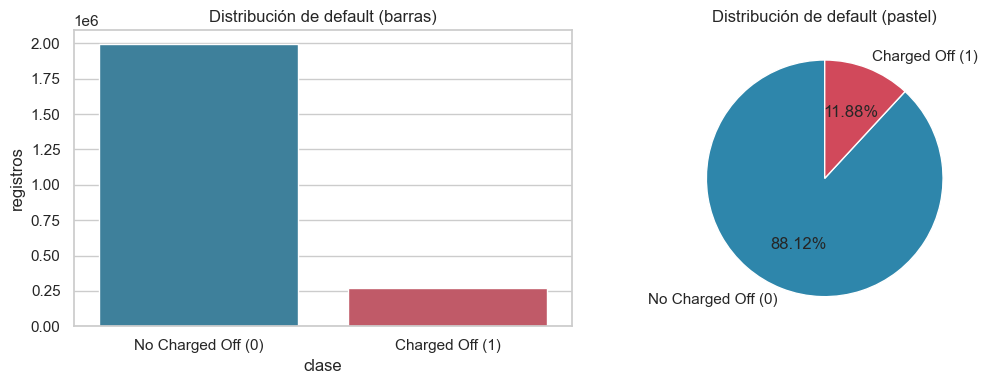

Clase minoritaria: 11.88%
Comentario: desbalance relevante. Conviene estratificar la partición train/test, usar métricas ponderadas (precision/recall/F1/ROC-AUC de la clase minoritaria) y considerar class_weight 


In [11]:
# Distribución de la variable objetivo: cuántos préstamos son default=0 vs default=1, en absolutos y %.
conteo = df["default"].value_counts().sort_index()
pct = df["default"].value_counts(normalize=True).sort_index() * 100
target_dist = pd.DataFrame({"clase": [CLASS_LABELS[k] for k in conteo.index],
                            "registros": conteo.values, "porcentaje": pct.values}, index=conteo.index)
display(target_dist)

# Un gráfico de barras y uno de pastel, lado a lado, mostrando lo mismo con dos formatos distintos.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=target_dist, x="clase", y="registros", ax=axes[0], palette=["#2E86AB", "#D1495B"])
axes[0].set_title("Distribución de default (barras)")
axes[1].pie(target_dist["registros"], labels=target_dist["clase"], autopct="%1.2f%%",
            colors=["#2E86AB", "#D1495B"], startangle=90)
axes[1].set_title("Distribución de default (pastel)")
plt.tight_layout()
plt.show()

# Comentario automático sobre si hay desbalance de clases (relevante para decidir estratificación,
# métricas ponderadas, etc. más adelante en el modelado); 20% es el umbral usado como referencia.
minoria_pct = pct.min()
print(f"Clase minoritaria: {minoria_pct:.2f}%")
if minoria_pct < 20:
    print("Comentario: desbalance relevante. Conviene estratificar la partición train/test, usar métricas "
          "ponderadas (precision/recall/F1/ROC-AUC de la clase minoritaria) y considerar class_weight "
          )
else:
    print("Comentario: las clases están razonablemente balanceadas; no sería estrictamente necesario aplicar "
          "balanceo en el modelado.")

### 9.10.4.1.3. Análisis bidimensional (relaciones entre variables)

#### Relación de cada variable numérica con `default`

Se usa **t de Student** cuando la variable es aproximadamente normal (según el criterio de asimetría de la
sección anterior) y **Mann-Whitney U** en caso contrario. Además se calcula la
correlación punto-biserial.

In [12]:

bivar_num_rows = []
for col in numeric_cols:
    s = pd.to_numeric(df[col], errors="coerce")
    temp = pd.DataFrame({col: s, "default": df["default"]}).dropna()
    if temp.shape[0] < 10 or temp["default"].nunique() < 2:
        continue   

    g0, g1 = temp.loc[temp["default"] == 0, col], temp.loc[temp["default"] == 1, col]
    if len(g0) < 3 or len(g1) < 3:
        continue   

   
  
    normal = bool(numeric_summary.loc[col, "normalidad"].startswith("Aproximadamente")) if col in numeric_summary.index else False
    if normal:
        stat, p = stats.ttest_ind(g0, g1, equal_var=False)
        prueba = "t de Student (Welch)"
    else:
        stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
        prueba = "Mann-Whitney U"
    
    pb_r, pb_p = stats.pointbiserialr(temp["default"], temp[col])

    bivar_num_rows.append({
        "variable": col, "media_default_0": g0.mean(), "media_default_1": g1.mean(),
        "diferencia_medias": g1.mean() - g0.mean(), "prueba": prueba, "estadistico": stat, "p_value": p,
        "significativo (p<0.05)": p < 0.05, "point_biserial_r": pb_r, "point_biserial_p": pb_p,
    })


bivar_numeric = pd.DataFrame(bivar_num_rows).sort_values("point_biserial_r", key=abs, ascending=False)
display(bivar_numeric)

,variable,media_default_0,media_default_1,diferencia_medias,prueba,estadistico,p_value,significativo (p<0.05),point_biserial_r,point_biserial_p
28,last_fico_range_high,703.732908,568.443236,-135.289672,t de Student (Welch),1.202776e+03,0.000000e+00,True,-0.599870,0.000000
29,last_fico_range_low,698.245741,507.111752,-191.133989,Mann-Whitney U,5.048243e+11,0.000000e+00,True,-0.556638,0.000000
25,recoveries,0.227103,1209.456926,1209.229823,Mann-Whitney U,8.359816e+10,0.000000e+00,True,0.522940,0.000000
26,collection_recovery_fee,0.047654,201.526243,201.478589,Mann-Whitney U,9.169414e+10,0.000000e+00,True,0.496764,0.000000
22,total_rec_prncp,10195.722044,4387.877516,-5807.844528,Mann-Whitney U,3.899104e+11,0.000000e+00,True,-0.225806,0.000000
...,...,...,...,...,...,...,...,...,...,...
43,total_bal_il,35491.797686,35664.202984,172.405298,Mann-Whitney U,7.453327e+10,1.079182e-50,True,0.001097,0.195238
36,tot_coll_amt,231.816813,239.577186,7.760373,Mann-Whitney U,2.450970e+11,3.358018e-119,True,0.000294,0.663705
32,policy_code,1.000000,1.000000,0.000000,t de Student (Welch),NaN,NaN,False,NaN,NaN
102,deferral_term,3.000000,3.000000,0.000000,t de Student (Welch),NaN,NaN,False,NaN,NaN


#### Relación de cada variable categórica con `default`
Crosstab con tasa de default por categoría, gráfico de barras apiladas y chi-cuadrado.

In [13]:
# Relación de cada variable CATEGÓRICA con el target 'default': tabla de contingencia + chi-cuadrado
# de independencia, y la tasa de default por categoría (para ver cuáles concentran más riesgo).
crosstabs_categoricas = {}
bivar_cat_rows = []

for col in categorical_cols:
    tmp = df[[col, "default"]].copy()
    tmp[col] = tmp[col].fillna("Missing").astype(str)   # los nulos se tratan como una categoría más aquí

    # Tabla de contingencia: filas = categorías, columnas = 0/1 de default, valores = conteos.
    ct = pd.crosstab(tmp[col], tmp["default"]).reindex(columns=[0, 1], fill_value=0)
    if ct.shape[0] < 2:
        continue   # una sola categoría: no tiene sentido probar independencia
    chi2, p, dof, _ = stats.chi2_contingency(ct)   # prueba de independencia chi-cuadrado

    # Igual que ct, pero normalizado por fila: da directamente la TASA de default dentro de cada categoría.
    rate = pd.crosstab(tmp[col], tmp["default"], normalize="index").reindex(columns=[0, 1], fill_value=0.0)
    rate = rate.sort_values(1, ascending=False)   # de mayor a menor tasa de default (columna 1)
    crosstabs_categoricas[col] = rate   # se guarda para reutilizarla en el gráfico de la siguiente celda

    bivar_cat_rows.append({
        "variable": col, "n_categorias": ct.shape[0], "chi2": chi2, "dof": dof, "p_value": p,
        "significativo (p<0.05)": p < 0.05,
        "categoria_mayor_riesgo": rate.index[0], "tasa_default_max": rate.iloc[0, 1],
    })

bivar_categorical = pd.DataFrame(bivar_cat_rows).sort_values("p_value")   # las más significativas primero
display(bivar_categorical)

,variable,n_categorias,chi2,dof,p_value,significativo (p<0.05),categoria_mayor_riesgo,tasa_default_max
0,term,3,1.614063e+04,2,0.000000e+00,True,60 months,0.161783
19,last_credit_pull_d,142,4.354728e+05,141,0.000000e+00,True,Oct-2016,0.760901
20,application_type,3,5.349470e+03,2,0.000000e+00,True,Individual,0.122533
21,verification_status_joint,4,4.821194e+03,3,0.000000e+00,True,Missing,0.122259
22,sec_app_earliest_cr_line,664,6.538202e+03,663,0.000000e+00,True,Dec-1965,1.000000
...,...,...,...,...,...,...,...,...
14,addr_state,52,3.230562e+03,51,0.000000e+00,True,AL,0.143894
16,initial_list_status,3,1.114536e+04,2,0.000000e+00,True,f,0.151846
23,hardship_flag,3,1.166546e+02,2,4.664268e-26,True,N,0.118840
8,pymnt_plan,3,8.805582e+01,2,7.566965e-20,True,n,0.118829


#### Multicolinealidad entre variables independientes

**Pearson** entre todas las numéricas y **V de Cramér** entre las categóricas (se excluyen las de cardinalidad
extrema, poco útiles y muy costosas de calcular). Se listan los pares por encima del umbral 0.70.

In [14]:
def cramers_v(x, y):
    """V de Cramér: mide la fuerza de asociación entre dos variables categóricas (0 = nada asociadas,
    1 = asociación perfecta); es el equivalente categórico de una correlación. Usa la corrección de sesgo
    de Bergsma (denominador ajustado por r y k) en vez de la fórmula simple, más fiable con muchas categorías."""
    tabla = pd.crosstab(x, y)
    if tabla.empty:
        return np.nan
    chi2 = stats.chi2_contingency(tabla, correction=False)[0]
    n = tabla.to_numpy().sum()
    if n <= 1:
        return np.nan
    r, k = tabla.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan


def pares_por_umbral(matrix, umbral, nombre_metrica):
    """De una matriz cuadrada de asociación (Pearson o Cramér), extrae solo los pares de variables
    (fuera de la diagonal, sin repetir i-j y j-i) cuyo valor absoluto supera el umbral dado."""
    filas = []
    cols = matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = matrix.iloc[i, j]
            if pd.notna(v) and abs(v) > umbral:
                filas.append({"variable_1": cols[i], "variable_2": cols[j], nombre_metrica: v})
    return pd.DataFrame(filas).sort_values(nombre_metrica, key=abs, ascending=False) if filas else pd.DataFrame(columns=["variable_1", "variable_2", nombre_metrica])


CORR_THRESHOLD = 0.70
corr_matrix_full = df[numeric_cols].corr(method="pearson")

pares_alta_corr_df = pares_por_umbral(corr_matrix_full, CORR_THRESHOLD, "r")
print(f"Pares numéricos con |r| > {CORR_THRESHOLD}: {len(pares_alta_corr_df)}")
display(pares_alta_corr_df)

Pares numéricos con |r| > 0.7: 76


,variable_1,variable_2,r
70,hardship_amount,orig_projected_additional_accrued_interest,1.000000
68,sec_app_fico_range_low,sec_app_fico_range_high,1.000000
21,fico_range_low,fico_range_high,1.000000
33,out_prncp,out_prncp_inv,0.999999
0,loan_amnt,funded_amnt,0.999755
...,...,...,...
10,funded_amnt,orig_projected_additional_accrued_interest,0.713146
4,loan_amnt,orig_projected_additional_accrued_interest,0.713146
15,funded_amnt_inv,orig_projected_additional_accrued_interest,0.713096
22,mths_since_last_delinq,mths_since_last_major_derog,0.706662


In [15]:
# Igual que la celda anterior, pero para categóricas usando V de Cramér en vez de Pearson.
# Se excluyen las de cardinalidad muy alta (más de 50 categorías distintas) porque calcular V de Cramér
# para todos los pares sería muy lento y, además, esas variables suelen ser identificadores de bajo valor.
MAX_CATEGORIAS_CRAMER = 50
categorical_cols_cramer = [c for c in categorical_cols if df[c].nunique(dropna=True) <= MAX_CATEGORIAS_CRAMER]
excluidas = [c for c in categorical_cols if c not in categorical_cols_cramer]
print(f"Categóricas incluidas en V de Cramér: {len(categorical_cols_cramer)} de {len(categorical_cols)}")
print(f"Excluidas por cardinalidad > {MAX_CATEGORIAS_CRAMER}: {excluidas}")

# Matriz cuadrada inicializada con 1 en la diagonal (una variable siempre está "perfectamente asociada"
# consigo misma) y se va llenando par por par.
cramer_full = pd.DataFrame(np.eye(len(categorical_cols_cramer)),
                           index=categorical_cols_cramer, columns=categorical_cols_cramer)
for c1, c2 in itertools.combinations(categorical_cols_cramer, 2):   # todos los pares únicos, sin repetir
    try:
        v = cramers_v(df[c1].fillna("Missing").astype(str), df[c2].fillna("Missing").astype(str))
    except (ValueError, MemoryError) as exc:
        print(f"No se pudo calcular V de Cramér para {c1} - {c2}: {exc}")
        v = np.nan
    cramer_full.loc[c1, c2] = cramer_full.loc[c2, c1] = v   # matriz simétrica: se llenan ambos lados a la vez



pares_alta_asociacion_cat_df = pares_por_umbral(cramer_full.astype(float), CORR_THRESHOLD, "cramers_v")
print(f"Pares categóricos con V de Cramér > {CORR_THRESHOLD}: {len(pares_alta_asociacion_cat_df)}")
display(pares_alta_asociacion_cat_df)

Categóricas incluidas en V de Cramér: 22 de 36
Excluidas por cardinalidad > 50: ['emp_title', 'issue_d', 'url', 'desc', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'sec_app_earliest_cr_line', 'debt_settlement_flag_date', 'settlement_date']
Pares categóricos con V de Cramér > 0.7: 70


,variable_1,variable_2,cramers_v
58,hardship_type,hardship_status,1.000000
62,hardship_type,hardship_loan_status,0.999999
57,hardship_type,hardship_reason,0.999998
61,hardship_type,payment_plan_start_date,0.999994
59,hardship_type,hardship_start_date,0.999994
...,...,...,...
30,verification_status,pymnt_plan,0.707107
54,hardship_flag,hardship_status,0.707106
69,debt_settlement_flag,settlement_status,0.707106
27,home_ownership,hardship_flag,0.707106


### 9.10.4.1.4. Valores faltantes (análisis detallado)

Cantidad y porcentaje de nulos por columna, visualización del patrón (`missingno` o, si no está disponible, un
heatmap propio de correlación entre indicadores de nulo), un **diagnóstico de asociación entre el indicador de
missingness y la variable objetivo** y un plan de tratamiento por variable.

> El diagnóstico compara la tasa de `default` entre filas con y sin dato faltante (con una prueba chi-cuadrado 2×2
> como apoyo). **No es una prueba formal de MCAR** (como la prueba de Little): solo indica si el hecho de faltar es
> informativo respecto a `default`.

In [16]:
# 9.10.4.1.4 — Valores faltantes: cantidad y porcentaje de nulos por columna, para TODAS las columnas
# del dataset (no solo numéricas/categóricas separadas), ordenado de la más incompleta a la más completa.
missing_summary = pd.DataFrame({
    "variable": df.columns,
    "n_missing": df.isna().sum().values,
    "pct_missing": (100 * df.isna().mean()).values,
}).sort_values("pct_missing", ascending=False).reset_index(drop=True)
display(missing_summary)

,variable,n_missing,pct_missing
0,orig_projected_additional_accrued_interest,2252050,99.617331
1,hardship_status,2249784,99.517097
2,hardship_type,2249784,99.517097
3,hardship_reason,2249784,99.517097
4,deferral_term,2249784,99.517097
...,...,...,...
148,total_pymnt,33,0.001460
149,hardship_flag,33,0.001460
150,member_id,0,0.000000
151,default,0,0.000000


In [17]:
cols_con_nulos = missing_summary.loc[(missing_summary["n_missing"] > 0) & (missing_summary["pct_missing"] < 100),
                                     "variable"].tolist()
MAX_COLS_VIZ = 40   # limitar columnas en los gráficos de nulos para que sigan siendo legibles
cols_viz = cols_con_nulos[:MAX_COLS_VIZ]

In [18]:
# Diagnóstico de asociación entre indicador de missingness y la variable objetivo.
# NO es una prueba formal de MCAR: compara la tasa de default con y sin faltante en cada variable,
# con una chi-cuadrado 2x2 (indicador_faltante x default) como apoyo descriptivo.
UMBRAL_DIF_MISSING = 0.02
y = df["default"].to_numpy()
filas_missing = []
for col in cols_con_nulos:
    m = df[col].isna().to_numpy()   # m = True donde esa columna tiene un valor faltante
    tasa_falta = y[m].mean() if m.any() else np.nan       # tasa de default ENTRE las filas donde falta col
    tasa_presente = y[~m].mean() if (~m).any() else np.nan   # tasa de default entre las filas donde NO falta
    # Tabla 2x2: (falta / no falta) x (default=1 / default=0), insumo del chi-cuadrado.
    tabla_2x2 = np.array([[np.sum(m & (y == 1)), np.sum(m & (y == 0))],
                          [np.sum(~m & (y == 1)), np.sum(~m & (y == 0))]])
    try:
        chi2_m, p_m = stats.chi2_contingency(tabla_2x2)[:2]
    except ValueError:   # ocurre si alguna fila/columna de la tabla queda en cero
        chi2_m, p_m = np.nan, np.nan
    filas_missing.append({
        "variable": col, "pct_missing": 100 * m.mean(),
        "tasa_default_si_falta": tasa_falta, "tasa_default_si_presente": tasa_presente,
        "diferencia": (tasa_falta - tasa_presente) if pd.notna(tasa_falta) and pd.notna(tasa_presente) else np.nan,
        "chi2": chi2_m, "p_value": p_m,
    })

missing_assoc = pd.DataFrame(filas_missing).sort_values("diferencia", key=lambda s: s.abs(), ascending=False)
# Se marca como "relevante" solo si la diferencia es grande (>= 2 puntos porcentuales) Y estadísticamente
# significativa (p < 0.05): evita señalar diferencias diminutas que son significativas solo por el
# enorme tamaño de la muestra.
missing_assoc["asociacion_relevante"] = (missing_assoc["diferencia"].abs() >= UMBRAL_DIF_MISSING) & (missing_assoc["p_value"] < 0.05)
print("Diagnóstico de asociación entre indicador de missingness y default "
      f"(se marca 'asociacion_relevante' si |diferencia| >= {UMBRAL_DIF_MISSING} y p < 0.05).")
print("Nota: esto no prueba ni descarta formalmente MCAR/MAR/MNAR; solo indica si el faltante es informativo sobre default.")
display(missing_assoc)

Diagnóstico de asociación entre indicador de missingness y default (se marca 'asociacion_relevante' si |diferencia| >= 0.02 y p < 0.05).
Nota: esto no prueba ni descarta formalmente MCAR/MAR/MNAR; solo indica si el faltante es informativo sobre default.


,variable,pct_missing,tasa_default_si_falta,tasa_default_si_presente,diferencia,chi2,p_value,asociacion_relevante
19,settlement_term,98.485160,0.105678,0.971530,-0.865851,241534.161883,0.000000e+00,True
18,settlement_amount,98.485160,0.105678,0.971530,-0.865851,241534.161883,0.000000e+00,True
17,settlement_date,98.485160,0.105678,0.971530,-0.865851,241534.161883,0.000000e+00,True
16,settlement_status,98.485160,0.105678,0.971530,-0.865851,241534.161883,0.000000e+00,True
15,debt_settlement_flag_date,98.485160,0.105678,0.971530,-0.865851,241534.161883,0.000000e+00,True
...,...,...,...,...,...,...,...,...
63,bc_util,3.366389,0.131360,0.118357,0.013003,118.655147,1.246157e-27,False
65,bc_open_to_buy,3.316140,0.131123,0.118372,0.012751,112.451820,2.844950e-26,False
66,mths_since_recent_bc,3.248771,0.131091,0.118382,0.012710,109.529184,1.242615e-25,False
42,mths_since_last_delinq,51.246715,0.112851,0.125042,-0.012191,801.755556,2.240640e-176,False


In [19]:
def plan_tratamiento(pct, tipo):
    """Traduce el % de faltantes (y el tipo de variable) en una recomendación de tratamiento concreta."""
    if pct == 0:
        return "sin acción"
    if pct > 70:
        return "eliminar columna (> 70% nulos)"
    if pct > 30:
        return "evaluar imputación avanzada (30%-70%) o crear indicador de faltante"
    if tipo == "numérica":
        return "imputar con mediana"
    return "imputar con moda o categoría 'Missing'"


tipo_por_col = {c: "numérica" for c in numeric_cols}
tipo_por_col.update({c: "categórica" for c in categorical_cols})

missing_summary["tipo"] = missing_summary["variable"].map(tipo_por_col).fillna("otra")
missing_summary["plan_tratamiento"] = [plan_tratamiento(p, t) for p, t in
                                       zip(missing_summary["pct_missing"], missing_summary["tipo"])]
display(missing_summary[missing_summary["n_missing"] > 0])   # solo se muestran las columnas que sí tienen algún nulo

,variable,n_missing,pct_missing,tipo,plan_tratamiento
0,orig_projected_additional_accrued_interest,2252050,99.617331,numérica,eliminar columna (> 70% nulos)
1,hardship_status,2249784,99.517097,categórica,eliminar columna (> 70% nulos)
2,hardship_type,2249784,99.517097,categórica,eliminar columna (> 70% nulos)
3,hardship_reason,2249784,99.517097,categórica,eliminar columna (> 70% nulos)
4,deferral_term,2249784,99.517097,numérica,eliminar columna (> 70% nulos)
...,...,...,...,...,...
145,fico_range_high,33,0.001460,numérica,imputar con mediana
146,fico_range_low,33,0.001460,numérica,imputar con mediana
147,total_rec_int,33,0.001460,numérica,imputar con mediana
148,total_pymnt,33,0.001460,numérica,imputar con mediana


### 9.10.4.1.5. Resumen ejecutivo del EDA

#### Identificación de variables de posible *data leakage* (información posterior a la originación)

Si tienes el diccionario de datos oficial de Lending Club (`LCDataDictionary.xlsx`), indica su ruta en
`DATA_DICT_PATH` y se usará su columna `Description` para detectar leakage. Si no lo tienes o no se puede leer,
se usa automáticamente un respaldo por patrón de nombre de columna (campos de pago, recuperación, hardship y
liquidación posteriores al desembolso), documentado según el diccionario público de Lending Club.

In [20]:
# 9.10.4.1.5 (parte 1) — Detección de variables con posible "data leakage": columnas que contienen
# información que solo se conoce DESPUÉS de que el préstamo ya incumplió o se resolvió (por ejemplo,
# cuánto se recuperó tras el default), y que por lo tanto no deberían usarse para predecirlo.
DATA_DICT_PATH = "https://raw.githubusercontent.com/juandpolo22/Diccionario_tarea1/main/LCDataDictionary.xlsx"

# Palabras clave que, en la DESCRIPCIÓN oficial de una columna, sugieren que es posterior al desenlace del préstamo.
PALABRAS_LEAKAGE = [
    "post charge off", "recovery", "recoveries", "received to date", "to date",
    "settlement", "last month", "next scheduled", "most recent", "remaining outstanding",
    "hardship", "hardship plan", "charged off",
    "last fico", "last total payment",  # <- agregadas: cubren last_fico_range_* y last_pymnt_amnt
]
# Respaldo cuando no se tiene el diccionario de datos: patrón sobre el NOMBRE de la columna que capta
# los mismos casos típicos (pagos totales, recuperaciones, fechas de último pago, planes de hardship, etc.).
PATRON_NOMBRE_LEAKAGE = (
    r"^(out_prncp|total_pymnt|total_rec_|recoveries|collection_recovery_fee|last_pymnt|next_pymnt|"
    r"last_credit_pull|last_fico|debt_settlement|settlement_|hardship_|pymnt_plan)"
)
FALSOS_POSITIVOS = [   # variables que el patrón podría marcar mal (son "meses desde", no posteriores al target)
    "mo_sin_rcnt_rev_tl_op", "mo_sin_rcnt_tl", "mths_since_last_major_derog", "mths_since_rcnt_il",
    "mths_since_recent_bc", "mths_since_recent_bc_dlq", "mths_since_recent_inq",
    "mths_since_recent_revol_delinq", "sec_app_mths_since_last_major_derog",
]

columnas_leakage = []
if DATA_DICT_PATH:
    # Camino preferido: si se tiene el diccionario oficial de Lending Club, se busca la palabra clave
    # dentro de la descripción real de cada columna (más confiable que adivinar por el nombre).
    try:
        dicc = pd.read_excel(DATA_DICT_PATH, sheet_name="LoanStats").dropna(subset=["LoanStatNew"])
        dicc["LoanStatNew"] = dicc["LoanStatNew"].str.strip()
        dicc["posible_leakage"] = dicc["Description"].apply(
            lambda d: any(p in str(d).lower() for p in PALABRAS_LEAKAGE) if pd.notna(d) else False)
        columnas_leakage = dicc.loc[dicc["posible_leakage"], "LoanStatNew"].tolist()
        print(f"Leakage detectado vía diccionario oficial: {len(columnas_leakage)} columnas.")
    except Exception as exc:
        print(f"[aviso] No se pudo leer el diccionario ({exc}); se usa el respaldo por patrón de nombre.")

if not columnas_leakage:
    # Camino de respaldo: sin diccionario, se aplica el patrón de nombre directamente sobre df.columns.
    import re
    columnas_leakage = [c for c in df.columns if re.match(PATRON_NOMBRE_LEAKAGE, c)]
    print(f"Leakage detectado vía patrón de nombre (respaldo): {len(columnas_leakage)} columnas.")

# Se descartan de la lista final las que ya se sabe que son falsos positivos del patrón de nombre.
columnas_leakage = [c for c in set(columnas_leakage) if c not in FALSOS_POSITIVOS]
display(pd.DataFrame({"variable": columnas_leakage}))

Leakage detectado vía diccionario oficial: 45 columnas.


,variable
0,hardship_length
1,settlement_term
2,recoveries
3,debt_settlement_flag
4,last_fico_range_high
...,...
31,total_pymnt_inv
32,hardship_flag
33,hardship_reason
34,hardship_type


In [21]:
MAX_CATEGORIAS_CANDIDATA = 50
categoricas_alta_cardinalidad = [c for c in categorical_cols if df[c].nunique(dropna=True) > MAX_CATEGORIAS_CANDIDATA]
print(f"Categóricas excluidas por cardinalidad > {MAX_CATEGORIAS_CANDIDATA}: {categoricas_alta_cardinalidad}")

Categóricas excluidas por cardinalidad > 50: ['emp_title', 'issue_d', 'url', 'desc', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d', 'sec_app_earliest_cr_line', 'debt_settlement_flag_date', 'settlement_date']


#### Variables más prometedoras para predecir `default`

Ranking combinado (numéricas por |correlación punto-biserial|, categóricas por V de Cramér), excluyendo
identificadores, `loan_status` y las columnas de leakage detectadas arriba, y sin quedarse con dos variables
redundantes entre sí (|Pearson| o V de Cramér > 0.70).

In [22]:
# 9.10.4.1.5 (parte 2) — Selección de las variables más prometedoras para predecir 'default':
# se combinan numéricas (por |correlación punto-biserial|) y categóricas (por V de Cramér) en un solo
# ranking, excluyendo leakage y evitando quedarse con dos variables muy redundantes entre sí.
N_TOP = 10
UMBRAL_REDUNDANCIA = 0.70

MAX_PCT_FALTANTES_CANDIDATA = 70
variables_alto_faltante = missing_summary.loc[
    missing_summary["pct_missing"] > MAX_PCT_FALTANTES_CANDIDATA, "variable"
].tolist()
print(f"Excluidas por >{MAX_PCT_FALTANTES_CANDIDATA}% de faltantes: {variables_alto_faltante}")

excluir = (set(["id", "member_id", "loan_status", "default"])
           | set(columnas_leakage)
           | set(categoricas_alta_cardinalidad)
           | set(variables_alto_faltante))

def cramers_v_vs_default(col):
    return cramers_v(df[col].fillna("Missing").astype(str), df["default"])

# Ranking de numéricas: fuerza = |correlación punto-biserial| con default (ya calculada en bivar_numeric).
rank_num = bivar_numeric[~bivar_numeric["variable"].isin(excluir)][["variable", "point_biserial_r", "p_value"]].copy()
rank_num["fuerza"] = rank_num["point_biserial_r"].abs()
rank_num["tipo"] = "numérica"

# Ranking de categóricas: fuerza = V de Cramér con default (se calcula aquí mismo, variable por variable).
rank_cat = bivar_categorical[~bivar_categorical["variable"].isin(excluir)][["variable", "p_value"]].copy()
rank_cat["fuerza"] = rank_cat["variable"].apply(cramers_v_vs_default)
rank_cat["tipo"] = "categórica"

# Se juntan ambos rankings en uno solo, se descartan las no significativas (p >= 0.05) y se ordena
# de mayor a menor fuerza de asociación con el target.
ranking = pd.concat([rank_num[["variable", "tipo", "fuerza", "p_value"]],
                     rank_cat[["variable", "tipo", "fuerza", "p_value"]]], ignore_index=True)
ranking = ranking[ranking["p_value"] < 0.05].sort_values("fuerza", ascending=False).reset_index(drop=True)


def es_redundante(candidata, tipo, elegidas):
    """Compara 'candidata' contra cada variable ya elegida del MISMO tipo: si están muy correlacionadas
    (Pearson para numéricas, Cramér para categóricas) por encima del umbral, se considera redundante
    y no aporta información nueva al conjunto ya seleccionado."""
    for var, t in elegidas:
        if tipo == "numérica" and t == "numérica" and candidata in corr_matrix_full.columns and var in corr_matrix_full.columns:
            r = corr_matrix_full.loc[candidata, var]
            if pd.notna(r) and abs(r) > UMBRAL_REDUNDANCIA:
                return True, f"|Pearson r|={abs(r):.2f} con '{var}'"
        if tipo == "categórica" and t == "categórica" and candidata in cramer_full.columns and var in cramer_full.columns:
            v = cramer_full.loc[candidata, var]
            if pd.notna(v) and v > UMBRAL_REDUNDANCIA:
                return True, f"V de Cramér={v:.2f} con '{var}'"
    return False, None


# Recorre el ranking de mayor a menor fuerza y va eligiendo variables en orden, saltándose las que
# resulten redundantes con alguna ya elegida, hasta completar N_TOP variables (o agotar el ranking).
elegidas, justificaciones, descartadas = [], [], []
for _, fila in ranking.iterrows():
    if len(elegidas) >= N_TOP:
        break
    redundante, motivo = es_redundante(fila["variable"], fila["tipo"], elegidas)
    if redundante:
        descartadas.append({"variable": fila["variable"], "tipo": fila["tipo"], "motivo": motivo})
        continue
    elegidas.append((fila["variable"], fila["tipo"]))
    metrica = "|correlación punto-biserial|" if fila["tipo"] == "numérica" else "V de Cramér"
    justificaciones.append({"variable": fila["variable"], "tipo": fila["tipo"], "metrica": metrica,
                            "valor_metrica": fila["fuerza"], "p_value": fila["p_value"]})

seleccion_final = pd.DataFrame(justificaciones)
print("Variables más prometedoras (sin leakage ni redundancia):")
display(seleccion_final)
if descartadas:
    print("Descartadas por redundancia con una variable ya elegida:")
    display(pd.DataFrame(descartadas))

Excluidas por >70% de faltantes: ['orig_projected_additional_accrued_interest', 'hardship_status', 'hardship_type', 'hardship_reason', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'hardship_end_date', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'settlement_percentage', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_term', 'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'revol_bal_joint', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_collections_12_mths_ex_med', 'sec_app_chargeoff_within_12_mths', 'sec_app_num_rev_accts', 'sec_app_open_act_il', 'sec_app_mort_acc', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_open_acc', 'verification_status_joint', 'dti_joint', 'annual_inc_joint', 'desc', 'mths_since_last_record', 'mths_since_recent_bc_dlq', 'mths_since_last_major_der

,variable,tipo,metrica,valor_metrica,p_value
0,sub_grade,categórica,V de Cramér,0.227241,0.0
1,int_rate,numérica,|correlación punto-biserial|,0.198918,0.0
2,fico_range_low,numérica,|correlación punto-biserial|,0.119437,0.0
3,verification_status,categórica,V de Cramér,0.094978,0.0
4,acc_open_past_24mths,numérica,|correlación punto-biserial|,0.093171,0.0
5,inq_last_6mths,numérica,|correlación punto-biserial|,0.083363,0.0
6,bc_open_to_buy,numérica,|correlación punto-biserial|,0.082013,0.0
7,percent_bc_gt_75,numérica,|correlación punto-biserial|,0.076392,0.0
8,inq_last_12m,numérica,|correlación punto-biserial|,0.071265,0.0
9,all_util,numérica,|correlación punto-biserial|,0.067825,0.0


Descartadas por redundancia con una variable ya elegida:


,variable,tipo,motivo
0,grade,categórica,V de Cramér=1.00 con 'sub_grade'
1,fico_range_high,numérica,|Pearson r|=1.00 con 'fico_range_low'
2,term,categórica,V de Cramér=0.76 con 'sub_grade'
3,num_tl_op_past_12m,numérica,|Pearson r|=0.76 con 'acc_open_past_24mths'
4,open_rv_24m,numérica,|Pearson r|=0.85 con 'acc_open_past_24mths'
5,total_bc_limit,numérica,|Pearson r|=0.84 con 'bc_open_to_buy'
6,bc_util,numérica,|Pearson r|=0.85 con 'percent_bc_gt_75'
7,initial_list_status,categórica,V de Cramér=0.71 con 'sub_grade'


### Justificación de la eliminación de variables

El dataset original contenia 2.260.701 filas y 151 columnas, un volumen que hace inviable e innecesario utilizar todas las variables tal cual: muchas de ellas no aportan valor predictivo, distorsionan las métricas de asociación y comprometerían la validez del modelo. Por eso, antes de llegar a las 10 variables finales, se aplicó un proceso de reducción en varias etapas. Primero se descartaron `id` y `member_id` por ser identificadores únicos sin relación causal con el riesgo de impago, y `loan_status` por ser la columna origen de la que se deriva literalmente el target. Después se identificaron y excluyeron las variables con *data leakage*: columnas que solo se conocen o cambian **después** de que el préstamo ya fue otorgado y está en curso (pagos recibidos, recuperaciones, montos de acuerdos de pago, fechas de últimos pagos, etc.), verificadas contra el diccionario oficial de datos —de incluirse, el modelo aprendería a partir de información que en producción todavía no existiría al momento de decidir el préstamo. También se eliminaron las categóricas de cardinalidad extrema (más de 50 categorías distintas, como `emp_title`, `title`, `desc` o `zip_code`), porque funcionan casi como texto libre o cuasi-identificadores e inflan artificialmente las métricas de asociación. Del universo restante, solo se conservaron las variables con asociación estadísticamente significativa con `default` (p < 0.05), y de esas, se filtraron las redundantes entre sí (alta correlación o V de Cramér con una variable ya elegida), para evitar quedarse con dos columnas que en la práctica miden lo mismo.

Las 10 variables de la tabla surgen de un proceso sistemático, no de un criterio arbitrario: primero se excluyeron los identificadores sin valor predictivo (`id`, `member_id`), la columna origen del target (`loan_status`), las variables con posible *data leakage* información posterior a la originación del préstamo, verificada contra el diccionario oficial de datos, las categóricas de cardinalidad extrema, y las variables con más de 70% de valores faltantes (mismo umbral que la regla de tratamiento de faltantes del EDA). Sobre el resto, se calculó la fuerza de asociación con `default` de forma comparable entre tipos de variable V de Cramér para categóricas, valor absoluto de la correlación punto-biserial para numéricas, reteniendo solo las asociaciones estadísticamente significativas (p < 0.05). El ranking resultante se recorrió de mayor a menor fuerza, descartando iterativamente cualquier candidata redundante (|Pearson r| o V de Cramér > 0.70) con una variable ya seleccionada, hasta completar las 10. El resultado mezcla variables numéricas y categóricas relacionadas con el perfil crediticio del solicitante (`sub_grade`, `int_rate`, `fico_range_low`, `verification_status`) y con su actividad crediticia reciente (`inq_last_6mths`, `acc_open_past_24mths`, `bc_open_to_buy`, `percent_bc_gt_75`, `inq_last_12m`, `all_util`). Dos candidatas del co-solicitante en préstamos conjuntos (`sec_app_fico_range_low`, `sec_app_inq_last_6mths`) fueron descartadas pese a tener buena asociación estadística, porque superan el 95% de valores faltantes; en su lugar entraron `inq_last_12m` y `all_util`, que rondan un 38% de faltantes cada una y faltan prácticamente en las mismas filas (99.97% de solapamiento) — un patrón que resultó ser fuertemente informativo sobre el target: la tasa de default casi se duplica en los solicitantes a quienes falta el dato (17.14% vs 8.61%, +8.5 puntos porcentuales, p<0.001). Por eso, en el preprocesamiento del modelado no basta con imputar la mediana en estas dos variables: se creará además un indicador binario de faltante (`inq_last_12m_missing` / `all_util_missing`) para conservar esa señal, en línea con la recomendación de "crear indicador de faltante" que ya contemplaba la tabla de decisión del EDA para el tramo 30%-70%. Cabe señalar que ninguna asociación individual con `default` es fuerte por sí sola (todas por debajo de 0.23): esto es esperable en un problema de riesgo crediticio, donde el poder predictivo suele residir en la combinación de variables más que en un único factor dominante, y respalda usar estas 10 (más los indicadores de faltante) como conjunto de entrada al modelado en lugar de depender de una sola.

In [23]:
tipo_por_variable = dict(zip(seleccion_final["variable"], seleccion_final["tipo"]))
numeric_cols_top = [v for v in seleccion_final["variable"] if tipo_por_variable[v] == "numérica"]
categorical_cols_top = [v for v in seleccion_final["variable"] if tipo_por_variable[v] == "categórica"]
print(f"Numéricas top ({len(numeric_cols_top)}): {numeric_cols_top}")
print(f"Categóricas top ({len(categorical_cols_top)}): {categorical_cols_top}")

Numéricas top (8): ['int_rate', 'fico_range_low', 'acc_open_past_24mths', 'inq_last_6mths', 'bc_open_to_buy', 'percent_bc_gt_75', 'inq_last_12m', 'all_util']
Categóricas top (2): ['sub_grade', 'verification_status']


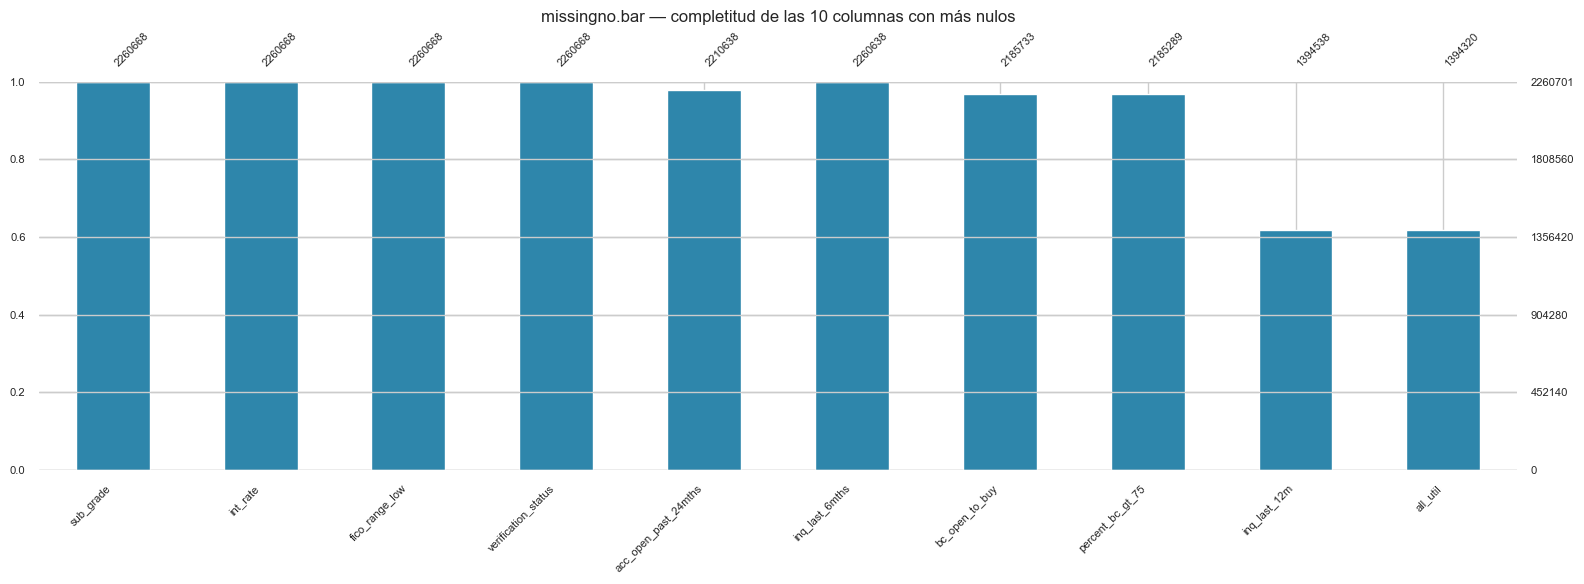

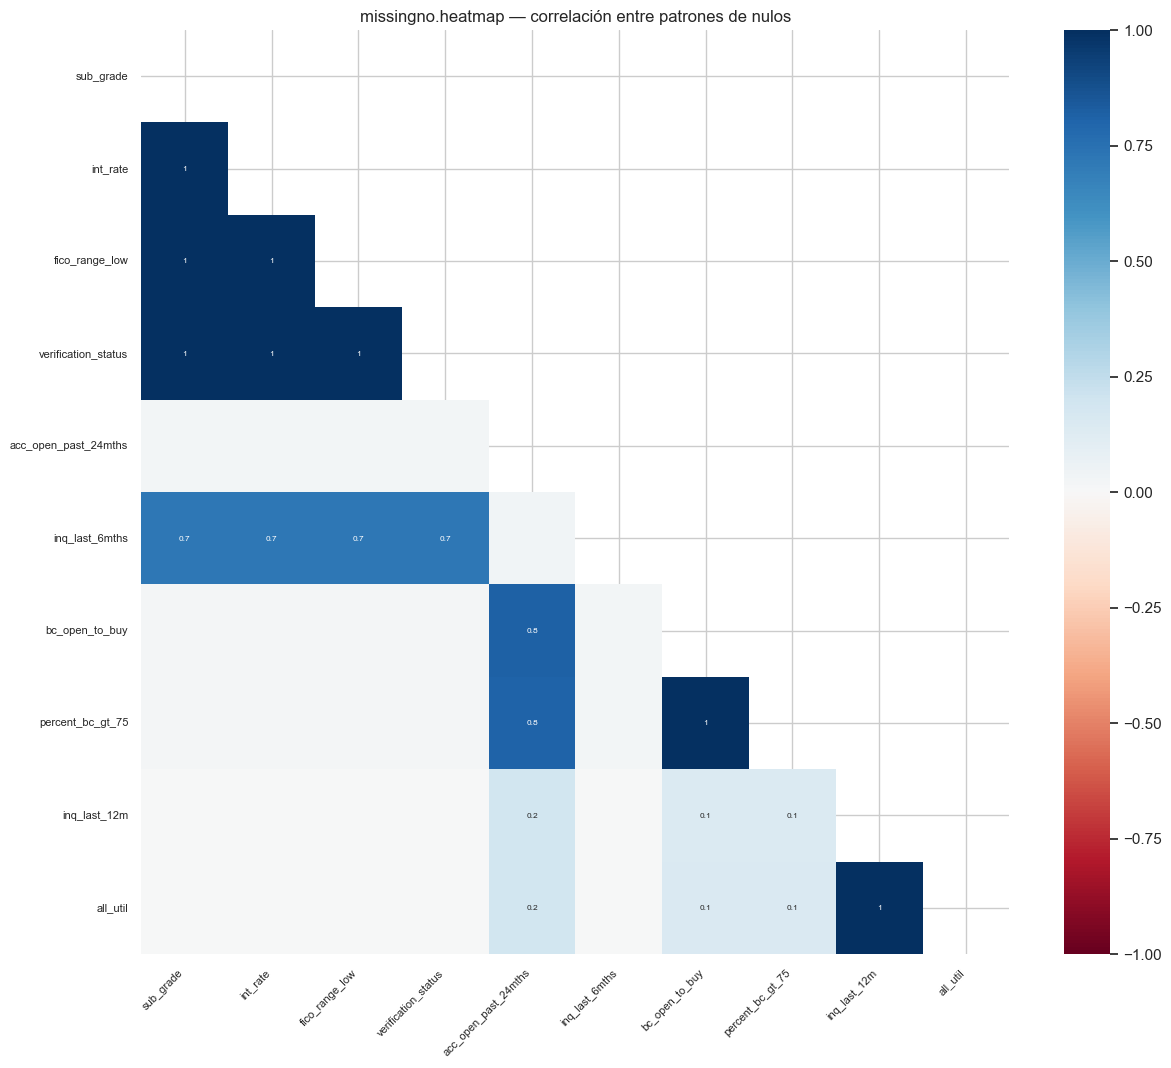

In [24]:
cols_con_nulos = missing_summary.loc[
    (missing_summary["n_missing"] > 0) &
    (missing_summary["pct_missing"] < 100),
    "variable"
].tolist()

MAX_COLS_VIZ = 40  # limitar columnas en los gráficos de nulos para que sigan siendo legibles

cols_viz = [
    v for v in seleccion_final["variable"]
    if v in cols_con_nulos
][:MAX_COLS_VIZ]


if MSNO_OK and cols_viz:
    msno.bar(
        df[cols_viz],
        figsize=(16, 6),
        fontsize=8,
        color="#2E86AB"
    )
    plt.title(
        f"missingno.bar — completitud de las {len(cols_viz)} columnas con más nulos"
    )
    plt.tight_layout()
    plt.show()

    msno.heatmap(
        df[cols_viz],
        figsize=(14, 12),
        fontsize=8
    )
    plt.title(
        "missingno.heatmap — correlación entre patrones de nulos"
    )
    plt.show()

elif cols_viz:
    null_corr = df[cols_viz].isna().astype(int).corr()

    plt.figure(
        figsize=(
            min(18, 0.35 * len(cols_viz) + 4),
            min(15, 0.35 * len(cols_viz) + 3)
        )
    )

    sns.heatmap(
        null_corr,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0
    )

    plt.title(
        "Correlación entre indicadores de nulo (respaldo sin missingno)"
    )
    plt.tight_layout()
    plt.show()

else:
    print("No hay columnas con nulos parciales para visualizar.")

El análisis de completitud evidencia que la mayoría de las variables presentan una alta disponibilidad de información, con proporciones de datos observados cercanas al 100 %. Sin embargo, las variables sec_app_fico_range_low y sec_app_no_late_... presentan una completitud cercana al 5 %, lo que indica una ausencia de información en aproximadamente el 95 % de las observaciones. Por tanto, estas variables requieren un análisis particular antes de definir su tratamiento, dado que su elevada proporción de valores faltantes podría limitar su utilidad para el modelamiento.

# Variable num


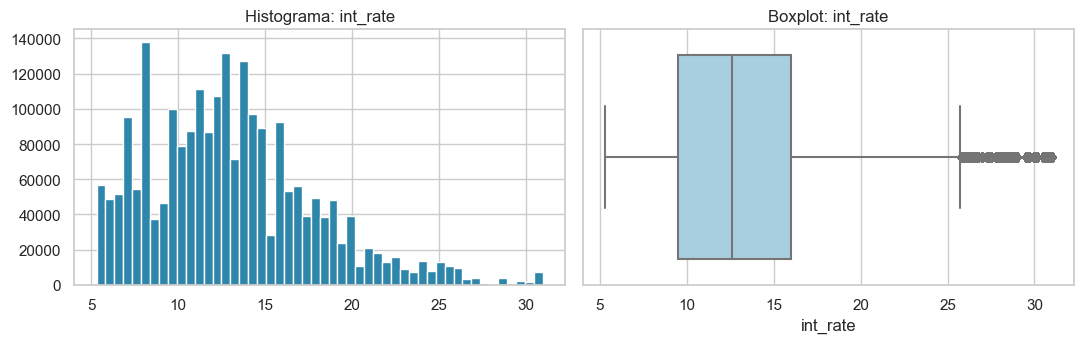

Q1=9.49 | mediana=12.62 | Q3=15.99 | IQR=6.50
Outliers (regla IQR): 41,099 de 2,260,668 (1.82%)
Asimetría: 0.77 — Aproximadamente normal (|skew|<=1)
Faltantes: 33 (0.00%) — Imputación simple (mediana)



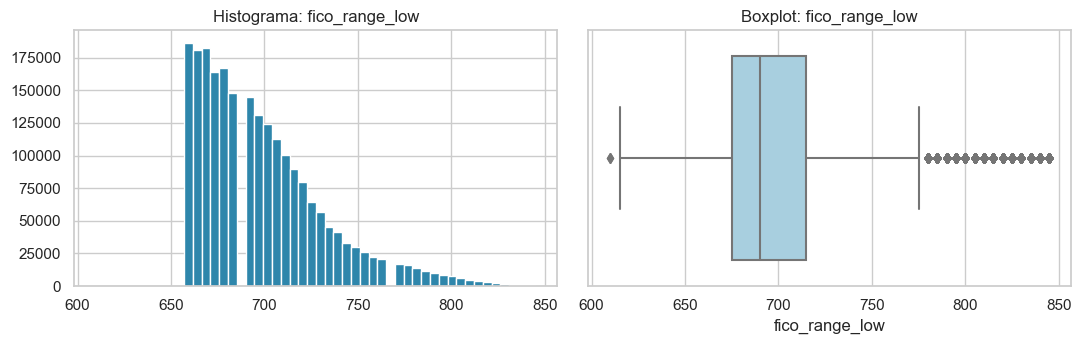

Q1=675.00 | mediana=690.00 | Q3=715.00 | IQR=40.00
Outliers (regla IQR): 74,846 de 2,260,668 (3.31%)
Asimetría: 1.19 — No normal / asimétrica -> considerar log o Box-Cox
Faltantes: 33 (0.00%) — Imputación simple (mediana)



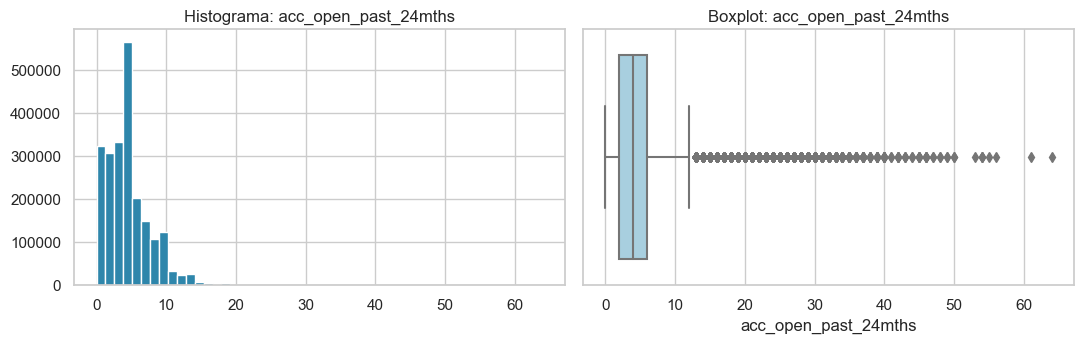

Q1=2.00 | mediana=4.00 | Q3=6.00 | IQR=4.00
Outliers (regla IQR): 48,076 de 2,210,638 (2.17%)
Asimetría: 1.40 — No normal / asimétrica -> considerar log o Box-Cox
Faltantes: 50,063 (2.21%) — Imputación simple (mediana)



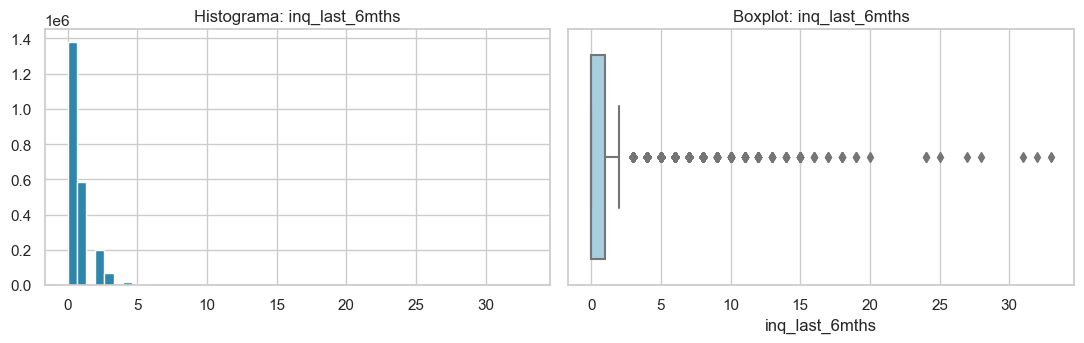

Q1=0.00 | mediana=0.00 | Q3=1.00 | IQR=1.00
Outliers (regla IQR): 94,314 de 2,260,638 (4.17%)
Asimetría: 2.07 — No normal / asimétrica -> considerar log o Box-Cox
Faltantes: 63 (0.00%) — Imputación simple (mediana)



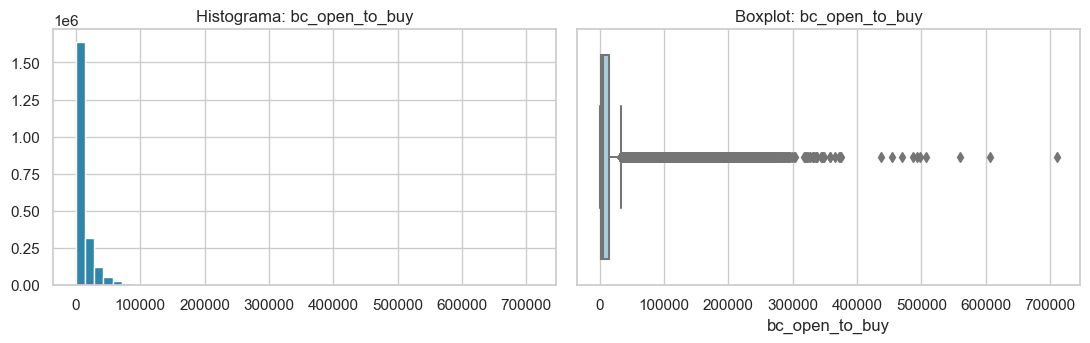

Q1=1722.00 | mediana=5442.00 | Q3=14187.00 | IQR=12465.00
Outliers (regla IQR): 180,429 de 2,185,733 (8.25%)
Asimetría: 3.74 — No normal / asimétrica -> considerar log o Box-Cox
Faltantes: 74,968 (3.32%) — Imputación simple (mediana)



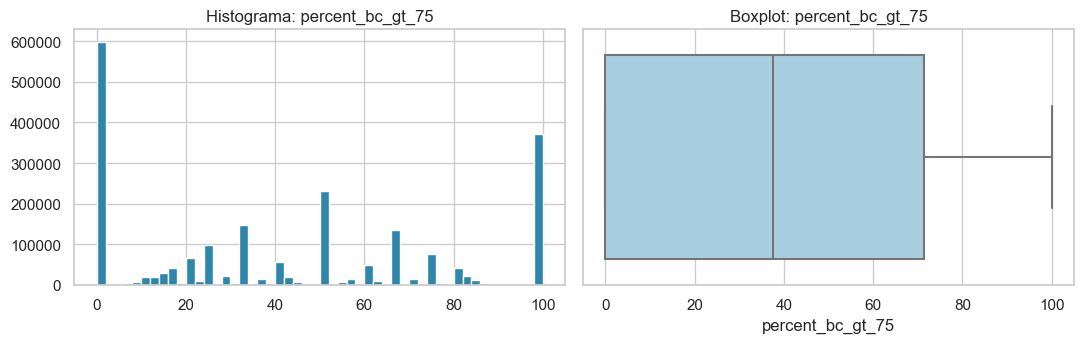

Q1=0.00 | mediana=37.50 | Q3=71.40 | IQR=71.40
Outliers (regla IQR): 0 de 2,185,289 (0.00%)
Asimetría: 0.31 — Aproximadamente normal (|skew|<=1)
Faltantes: 75,412 (3.34%) — Imputación simple (mediana)



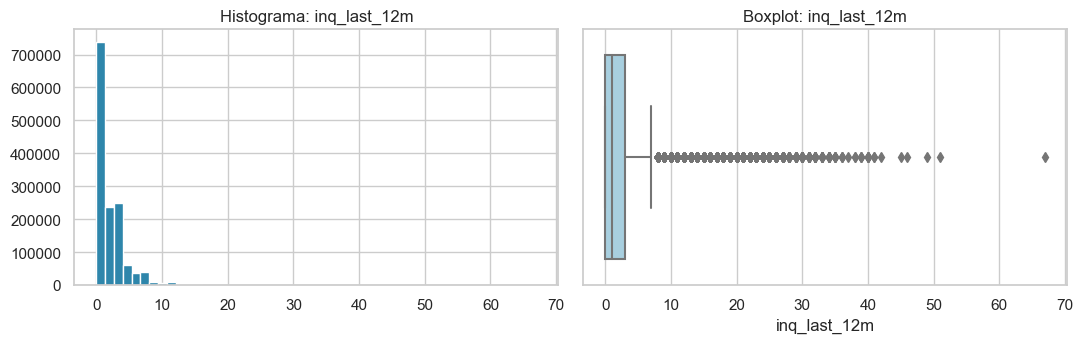

Q1=0.00 | mediana=1.00 | Q3=3.00 | IQR=3.00
Outliers (regla IQR): 47,487 de 1,394,538 (3.41%)
Asimetría: 2.41 — No normal / asimétrica -> considerar log o Box-Cox
Faltantes: 866,163 (38.31%) — Evaluar imputación avanzada (30%-70%)



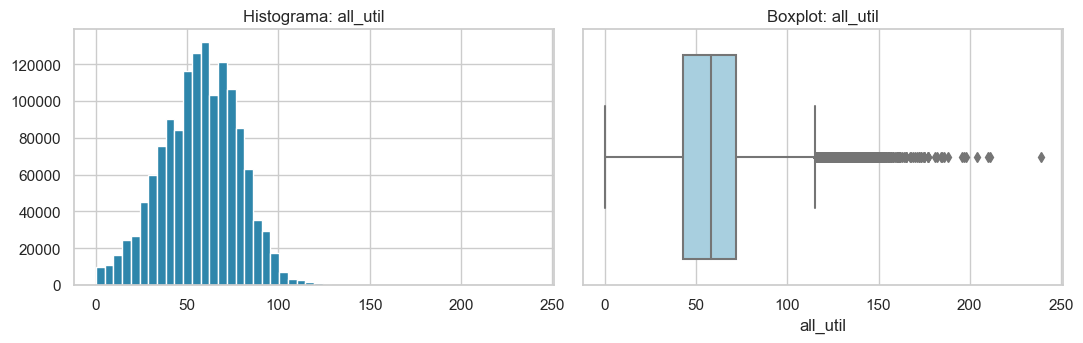

Q1=43.00 | mediana=58.00 | Q3=72.00 | IQR=29.00
Outliers (regla IQR): 3,211 de 1,394,320 (0.23%)
Asimetría: -0.12 — Aproximadamente normal (|skew|<=1)
Faltantes: 866,381 (38.32%) — Evaluar imputación avanzada (30%-70%)



In [25]:
# Un histograma + un boxplot por cada variable numérica: el histograma muestra la forma de la 
# distribución (sesgo, modas) y el boxplot resalta la mediana, el IQR y los outliers de un vistazo. 
for col in numeric_cols_top: 
    valid = pd.to_numeric(df[col], errors="coerce").dropna() 
    if valid.empty:   # nada que graficar si la columna no tiene datos numéricos válidos 
        continue 
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6)) 
    axes[0].hist(valid, bins=50, color="#2E86AB", edgecolor="white") 
    axes[0].set_title(f"Histograma: {col}") 
    sns.boxplot(x=valid, ax=axes[1], color="#9FD3E8") 
    axes[1].set_title(f"Boxplot: {col}") 
    plt.tight_layout() 
    plt.show() 
 
    fila = numeric_summary.loc[col] 
    print(f"Q1={fila['q25']:.2f} | mediana={fila['median']:.2f} | Q3={fila['q75']:.2f} | IQR={fila['IQR']:.2f}") 
    print(f"Outliers (regla IQR): {int(fila['outliers_IQR_n']):,} de {int(fila['count']):,} " 
          f"({fila['outliers_IQR_pct']:.2f}%)") 
    print(f"Asimetría: {fila['skewness']:.2f} — {fila['normalidad']}") 
    print(f"Faltantes: {int(fila['missing_n']):,} ({fila['missing_pct']:.2f}%) — {fila['decision_faltantes']}") 
    print() 

# Variable cat

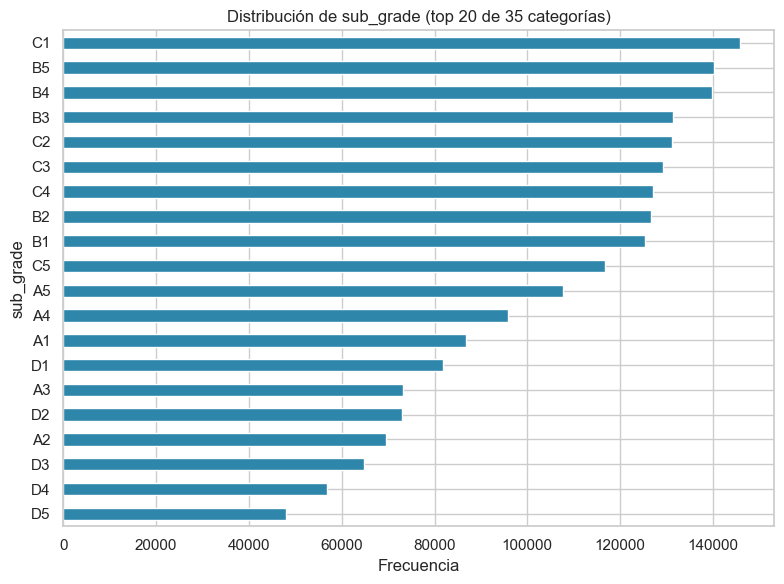

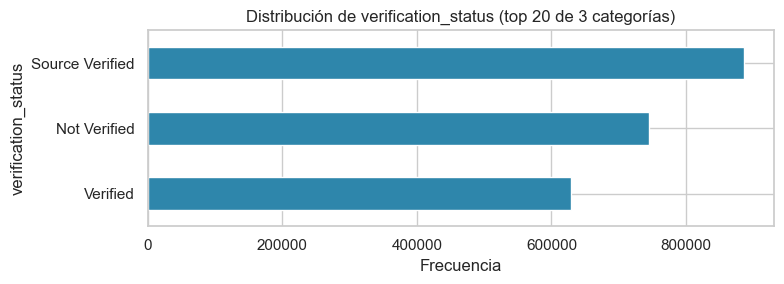

In [26]:
# Un gráfico de barras horizontales por variable categórica, con el top 20 de categorías más frecuentes
# (si hay más de 20, se recorta para que el gráfico siga siendo legible; el título indica el total real).
for col in categorical_cols_top:
    vc = df[col].value_counts(dropna=True).head(20)
    if vc.empty:
        continue
    plt.figure(figsize=(8, max(3, 0.3 * len(vc))))
    vc.plot(kind="barh", color="#2E86AB")
    plt.title(f"Distribución de {col} (top 20 de {df[col].nunique()} categorías)")
    plt.xlabel("Frecuencia")
    plt.gca().invert_yaxis()   # para que la categoría más frecuente quede arriba, no abajo
    plt.tight_layout()
    plt.show()

### 1. Distribución de variables categóricas

`sub_grade` muestra una distribución relativamente pareja entre B y C (los 9 subgrados más frecuentes concentran ~53% del dataset), con caída gradual hacia A y D. `verification_status` está repartida en tercios similares (39% Source Verified, 33% Not Verified, 28% Verified), sin una categoría dominante.

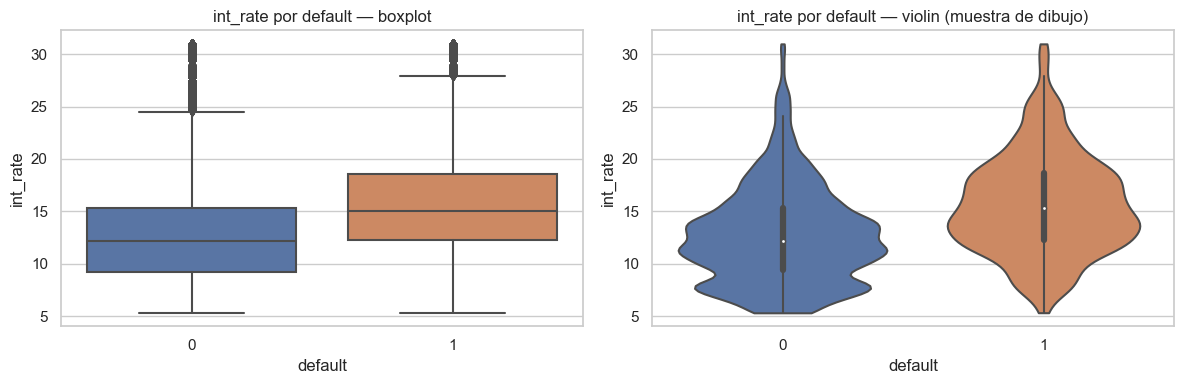

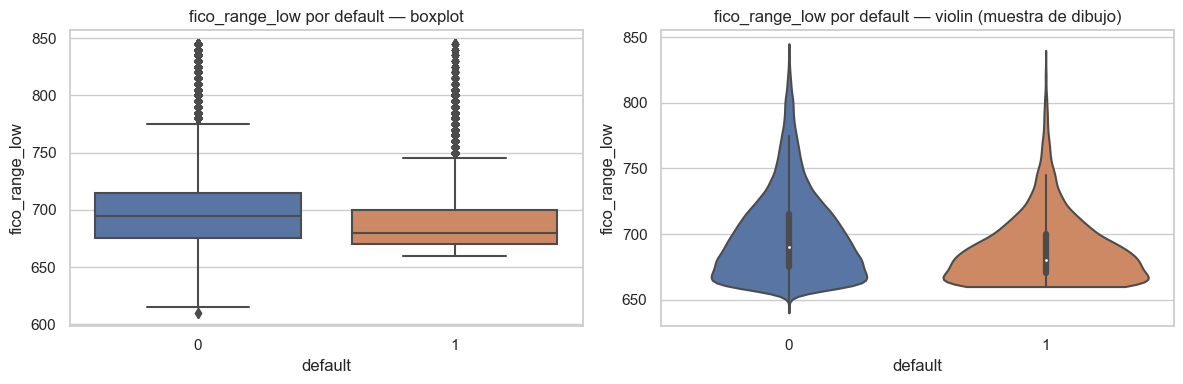

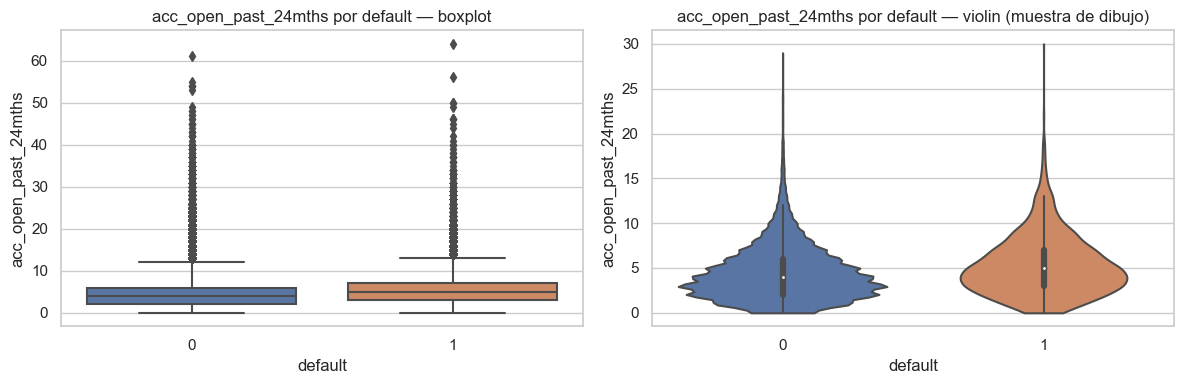

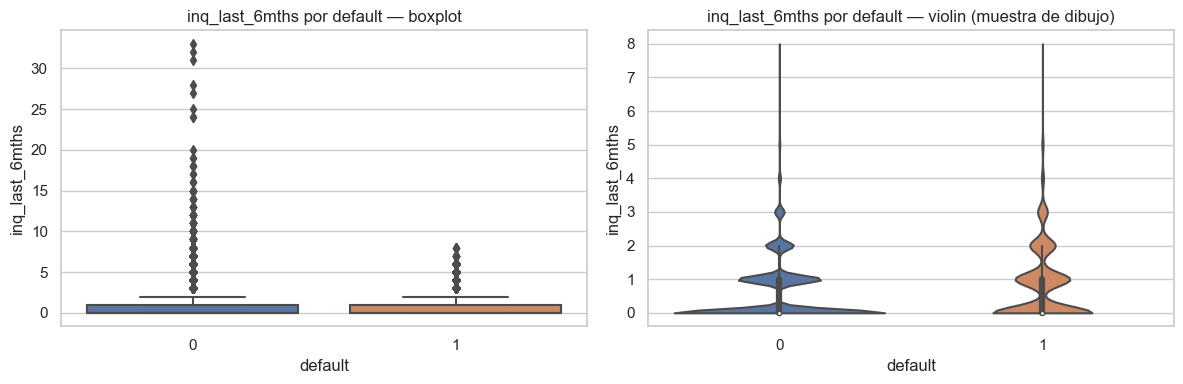

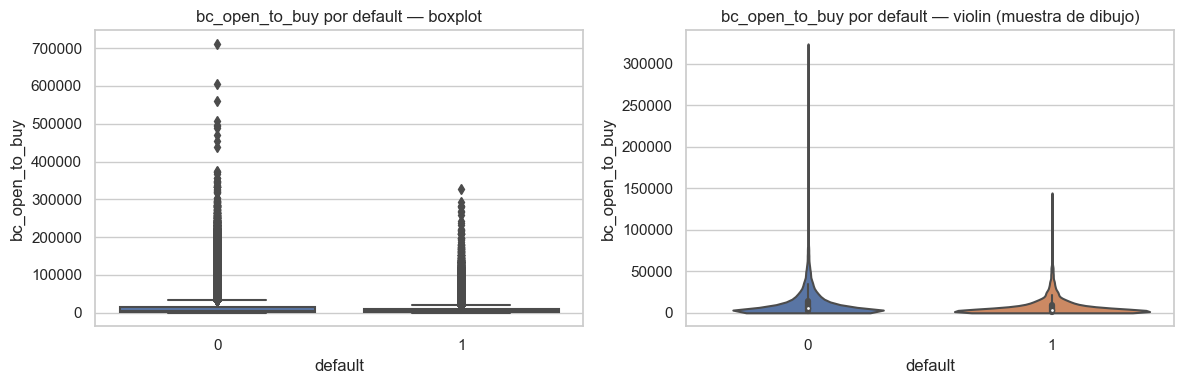

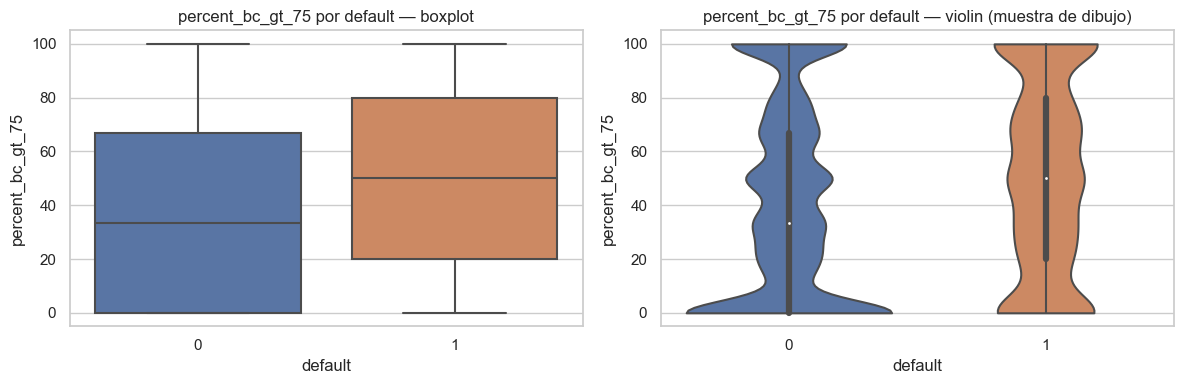

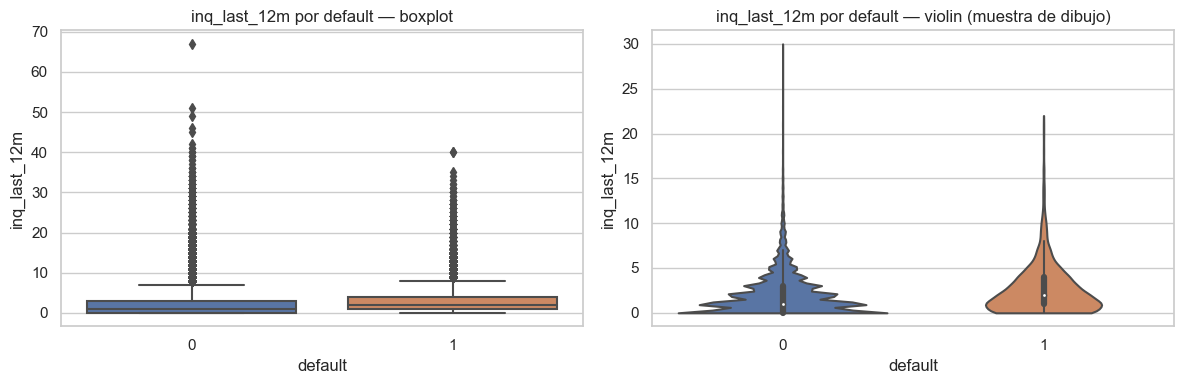

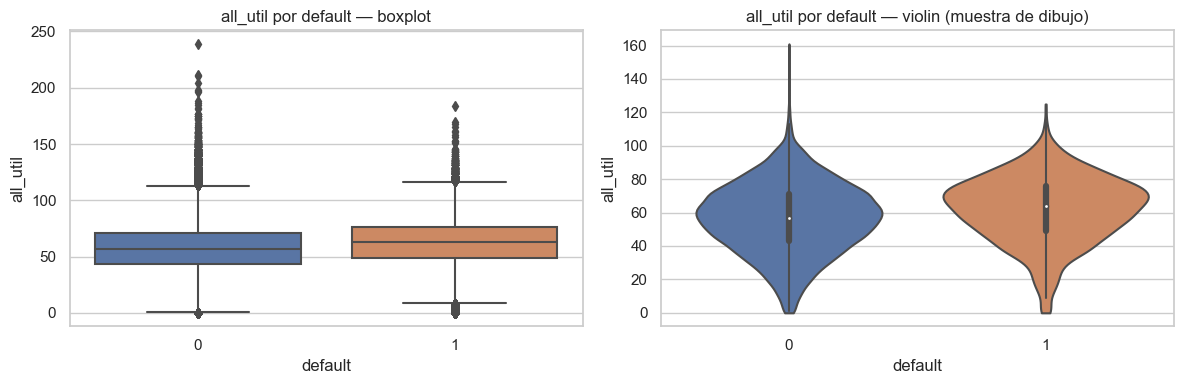

In [27]:
# La muestra se utiliza exclusivamente para visualización. Los cálculos estadísticos y el modelado utilizan el dataset completo.
# Boxplot (con TODOS los datos) + violin plot (con una muestra, solo para que el dibujo sea manejable)
# de cada variable numérica, separada por clase de default.
for col in numeric_cols_top:
    temp = df[[col, "default"]].copy()
    temp[col] = pd.to_numeric(temp[col], errors="coerce")
    temp = temp.dropna()
    if temp.shape[0] < 10 or temp["default"].nunique() < 2:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(data=temp, x="default", y=col, ax=axes[0])   # usa el dataset completo (temp), sin muestreo
    axes[0].set_title(f"{col} por default — boxplot")
    # Violin: la muestra se utiliza exclusivamente para visualización. Los cálculos estadísticos y el
    # modelado utilizan el dataset completo (el boxplot de la izquierda y las pruebas de arriba usan todas las filas).
    vis = temp.sample(n=min(30_000, len(temp)), random_state=RANDOM_STATE)
    sns.violinplot(data=vis, x="default", y=col, ax=axes[1], cut=0)
    axes[1].set_title(f"{col} por default — violin (muestra de dibujo)")
    plt.tight_layout()
    plt.show()
    plt.close(fig)   # libera memoria de la figura antes de pasar a la siguiente variable

### 2. Variables numéricas por clase de default

Al separar las numéricas por clase de default, cuatro variables muestran un desplazamiento visible y consistente entre boxplot y violin: `int_rate` y `percent_bc_gt_75` son más altas en los préstamos que terminan en Charged Off, mientras que `fico_range_low` y `bc_open_to_buy` son más bajas — es decir, tasas más altas, tarjetas más cerca del límite, peor score de crédito y menos cupo disponible se asocian con mayor riesgo, en la dirección que la intuición de negocio esperaría. Las cuatro restantes (`acc_open_past_24mths`, `inq_last_6mths`, `inq_last_12m`, `all_util`) muestran el mismo sentido de desplazamiento pero mucho más leve, con las distribuciones de ambas clases casi superpuestas.

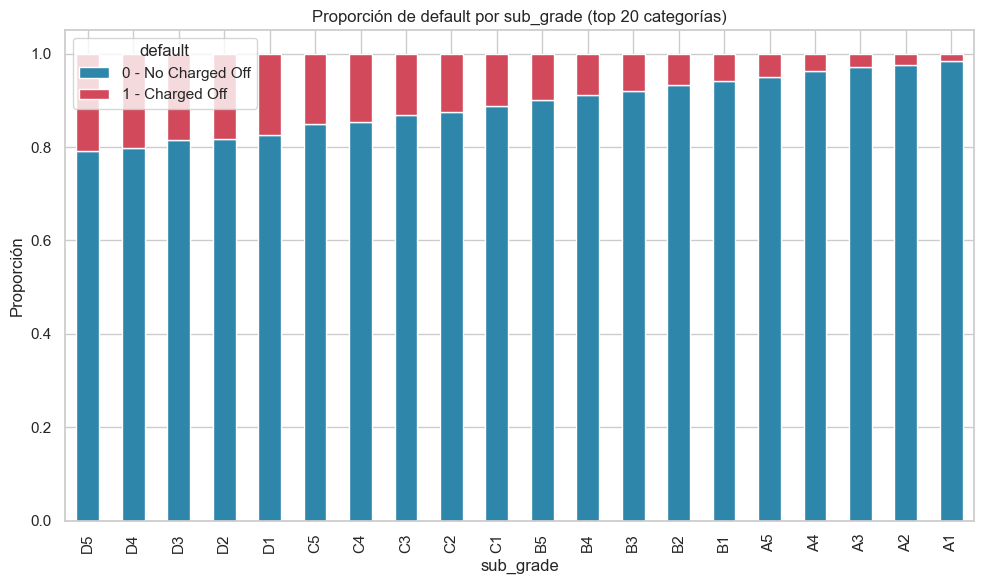

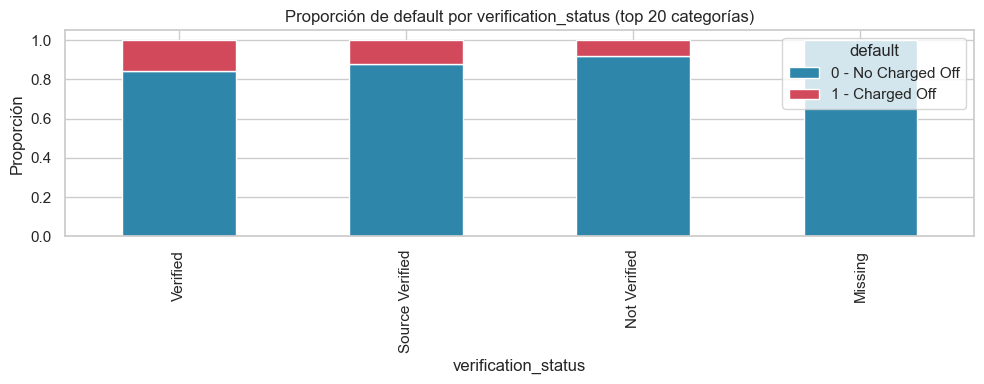

In [28]:
# Gráfico de barras apiladas por variable categórica: para cada una de sus top-20 categorías, qué
# proporción de préstamos son default=0 (azul) vs default=1 (rojo). Reutiliza 'rate' de la celda anterior.
for col in categorical_cols_top:
    rate = crosstabs_categoricas.get(col)
    if rate is None:
        continue
    top = df[col].fillna("Missing").astype(str).value_counts().head(20).index
    plot_ct = rate.loc[rate.index.isin(top)]
    fig = plt.figure(figsize=(10, max(4, 0.3 * len(plot_ct))))
    plot_ct.plot(kind="bar", stacked=True, ax=plt.gca(), color=["#2E86AB", "#D1495B"])
    plt.title(f"Proporción de default por {col} (top 20 categorías)")
    plt.ylabel("Proporción")
    plt.legend(title="default", labels=["0 - No Charged Off", "1 - Charged Off"])
    plt.tight_layout()
    plt.show()
    plt.close(fig)

#### Visualizaciones avanzadas

Se seleccionan las **5-6 variables numéricas más asociadas con `default`** (mayor |correlación punto-biserial|,
sección anterior) para el KDE, el scatter matrix y el pairplot.

- El **KDE** se calcula con todas las filas.
- El **scatter matrix** y el **pairplot** no son viables con más de un millón de puntos por panel, así que usan una
  muestra temporal y desechable.

> **La muestra se utiliza exclusivamente para visualización. Los cálculos estadísticos y el modelado utilizan el
> dataset completo.** `df` no se modifica (se verifica al final de la celda).

Variables seleccionadas para las visualizaciones avanzadas: ['int_rate', 'fico_range_low', 'acc_open_past_24mths', 'inq_last_6mths', 'bc_open_to_buy', 'percent_bc_gt_75', 'inq_last_12m', 'all_util']


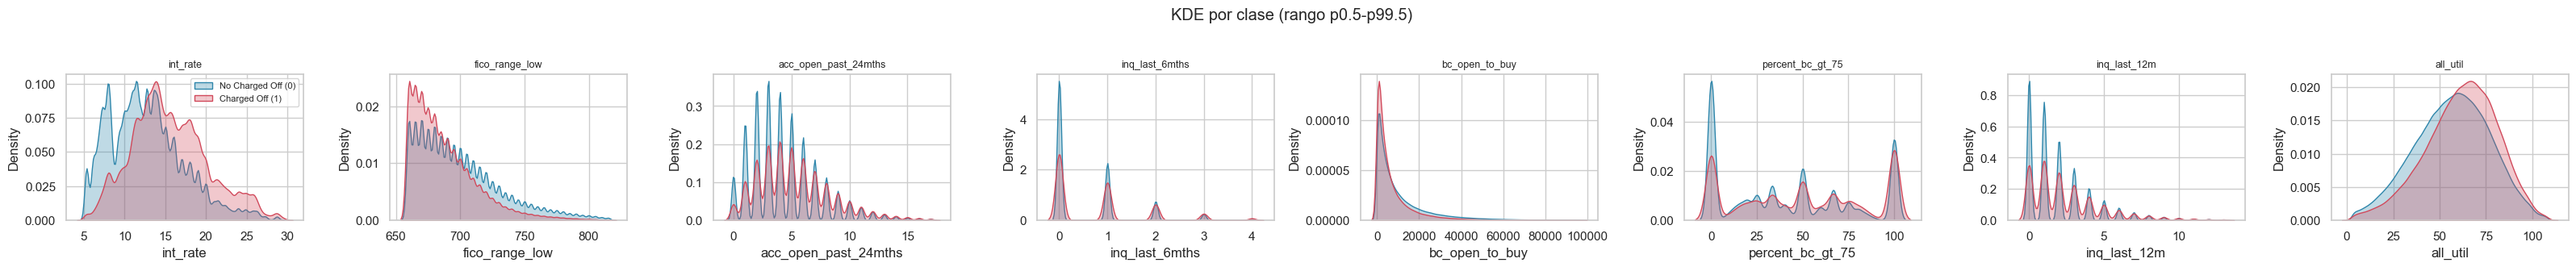

In [29]:
# Visualizaciones avanzadas (1/2): se usan las variables NUMÉRICAS del top 10 ya seleccionado
# (numeric_cols_top), no un top aparte, para mantener consistencia con la selección final de variables.
top_numericas_viz = numeric_cols_top
print(f"Variables seleccionadas para las visualizaciones avanzadas: {top_numericas_viz}")

# --- KDE por clase (con todos los datos, sin muestreo) ---
# Un panel por variable, con dos curvas de densidad superpuestas (default=0 y default=1).
fig, axes = plt.subplots(1, len(top_numericas_viz), figsize=(4 * len(top_numericas_viz), 3.2))
axes = np.atleast_1d(axes)   # por si solo hay 1 variable, subplots devuelve un único Axes en vez de un array
for ax, col in zip(axes, top_numericas_viz):
    s = pd.to_numeric(df[col], errors="coerce")
    lo, hi = s.quantile([0.005, 0.995])   # recorta el 0.5% de cada extremo para que un outlier no aplaste la escala
    for k, color in ((0, "#2E86AB"), (1, "#D1495B")):
        vals = s[df["default"] == k].dropna()
        vals = vals[(vals >= lo) & (vals <= hi)]
        sns.kdeplot(vals, ax=ax, color=color, label=CLASS_LABELS[k], fill=True, alpha=0.3, warn_singular=False)
    ax.set_title(col, fontsize=9)
axes[0].legend(fontsize=8)
fig.suptitle("KDE por clase (rango p0.5-p99.5)", y=1.03)
plt.tight_layout()
plt.show()

### 3. Distribución KDE por clase de default

Las curvas de densidad confirman lo observado en los boxplots/violines: `int_rate`, `fico_range_low` y `percent_bc_gt_75` muestran curvas claramente desplazadas entre las dos clases, mientras que `acc_open_past_24mths`, `inq_last_6mths`, `bc_open_to_buy`, `inq_last_12m` y `all_util` muestran curvas prácticamente superpuestas, con solo un ligero corrimiento hacia valores más altos (o más bajos, según el caso) en la clase Charged Off.

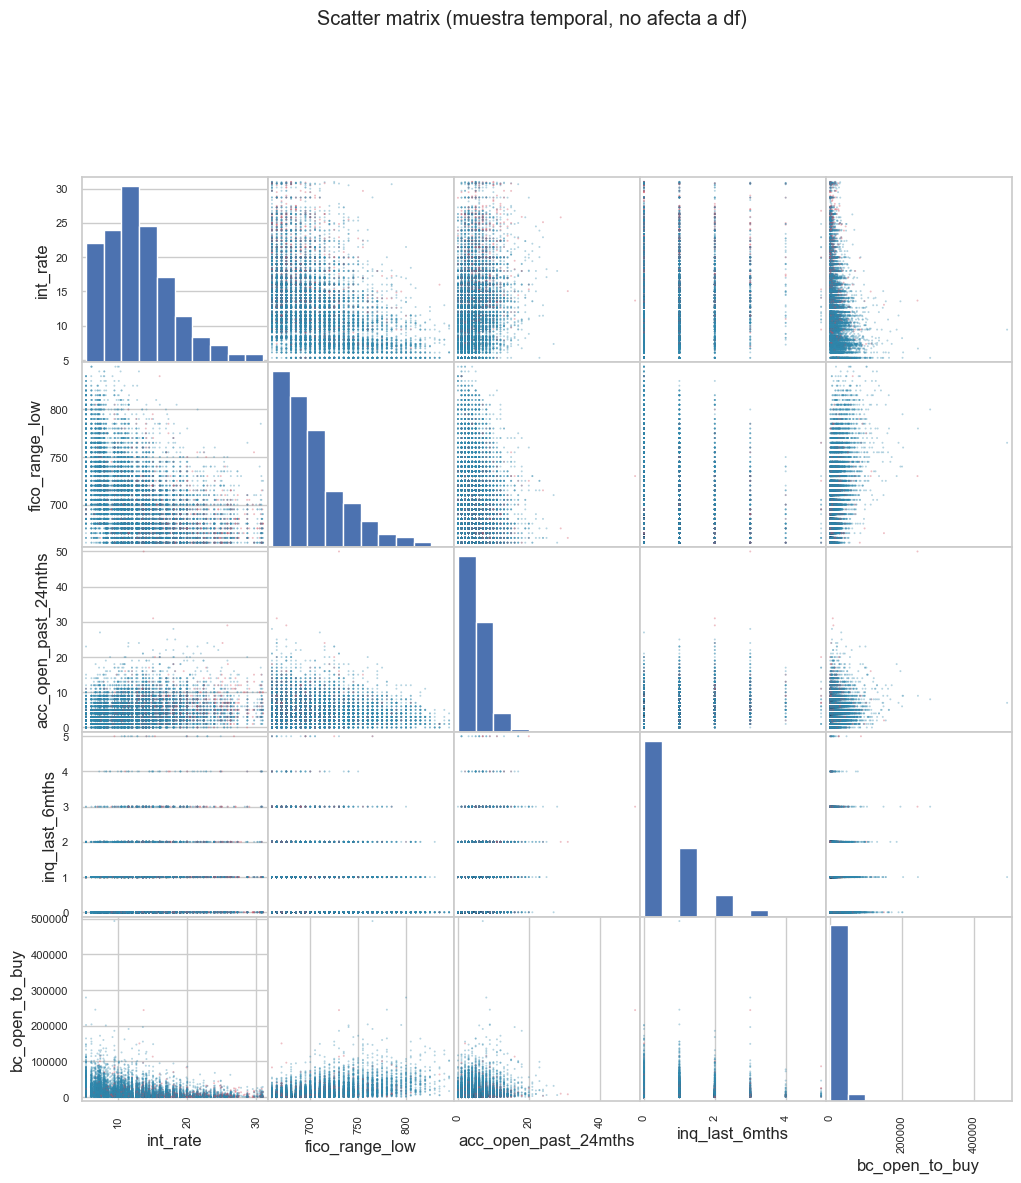

c:\Users\juand\miniconda3\envs\ml_venv\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


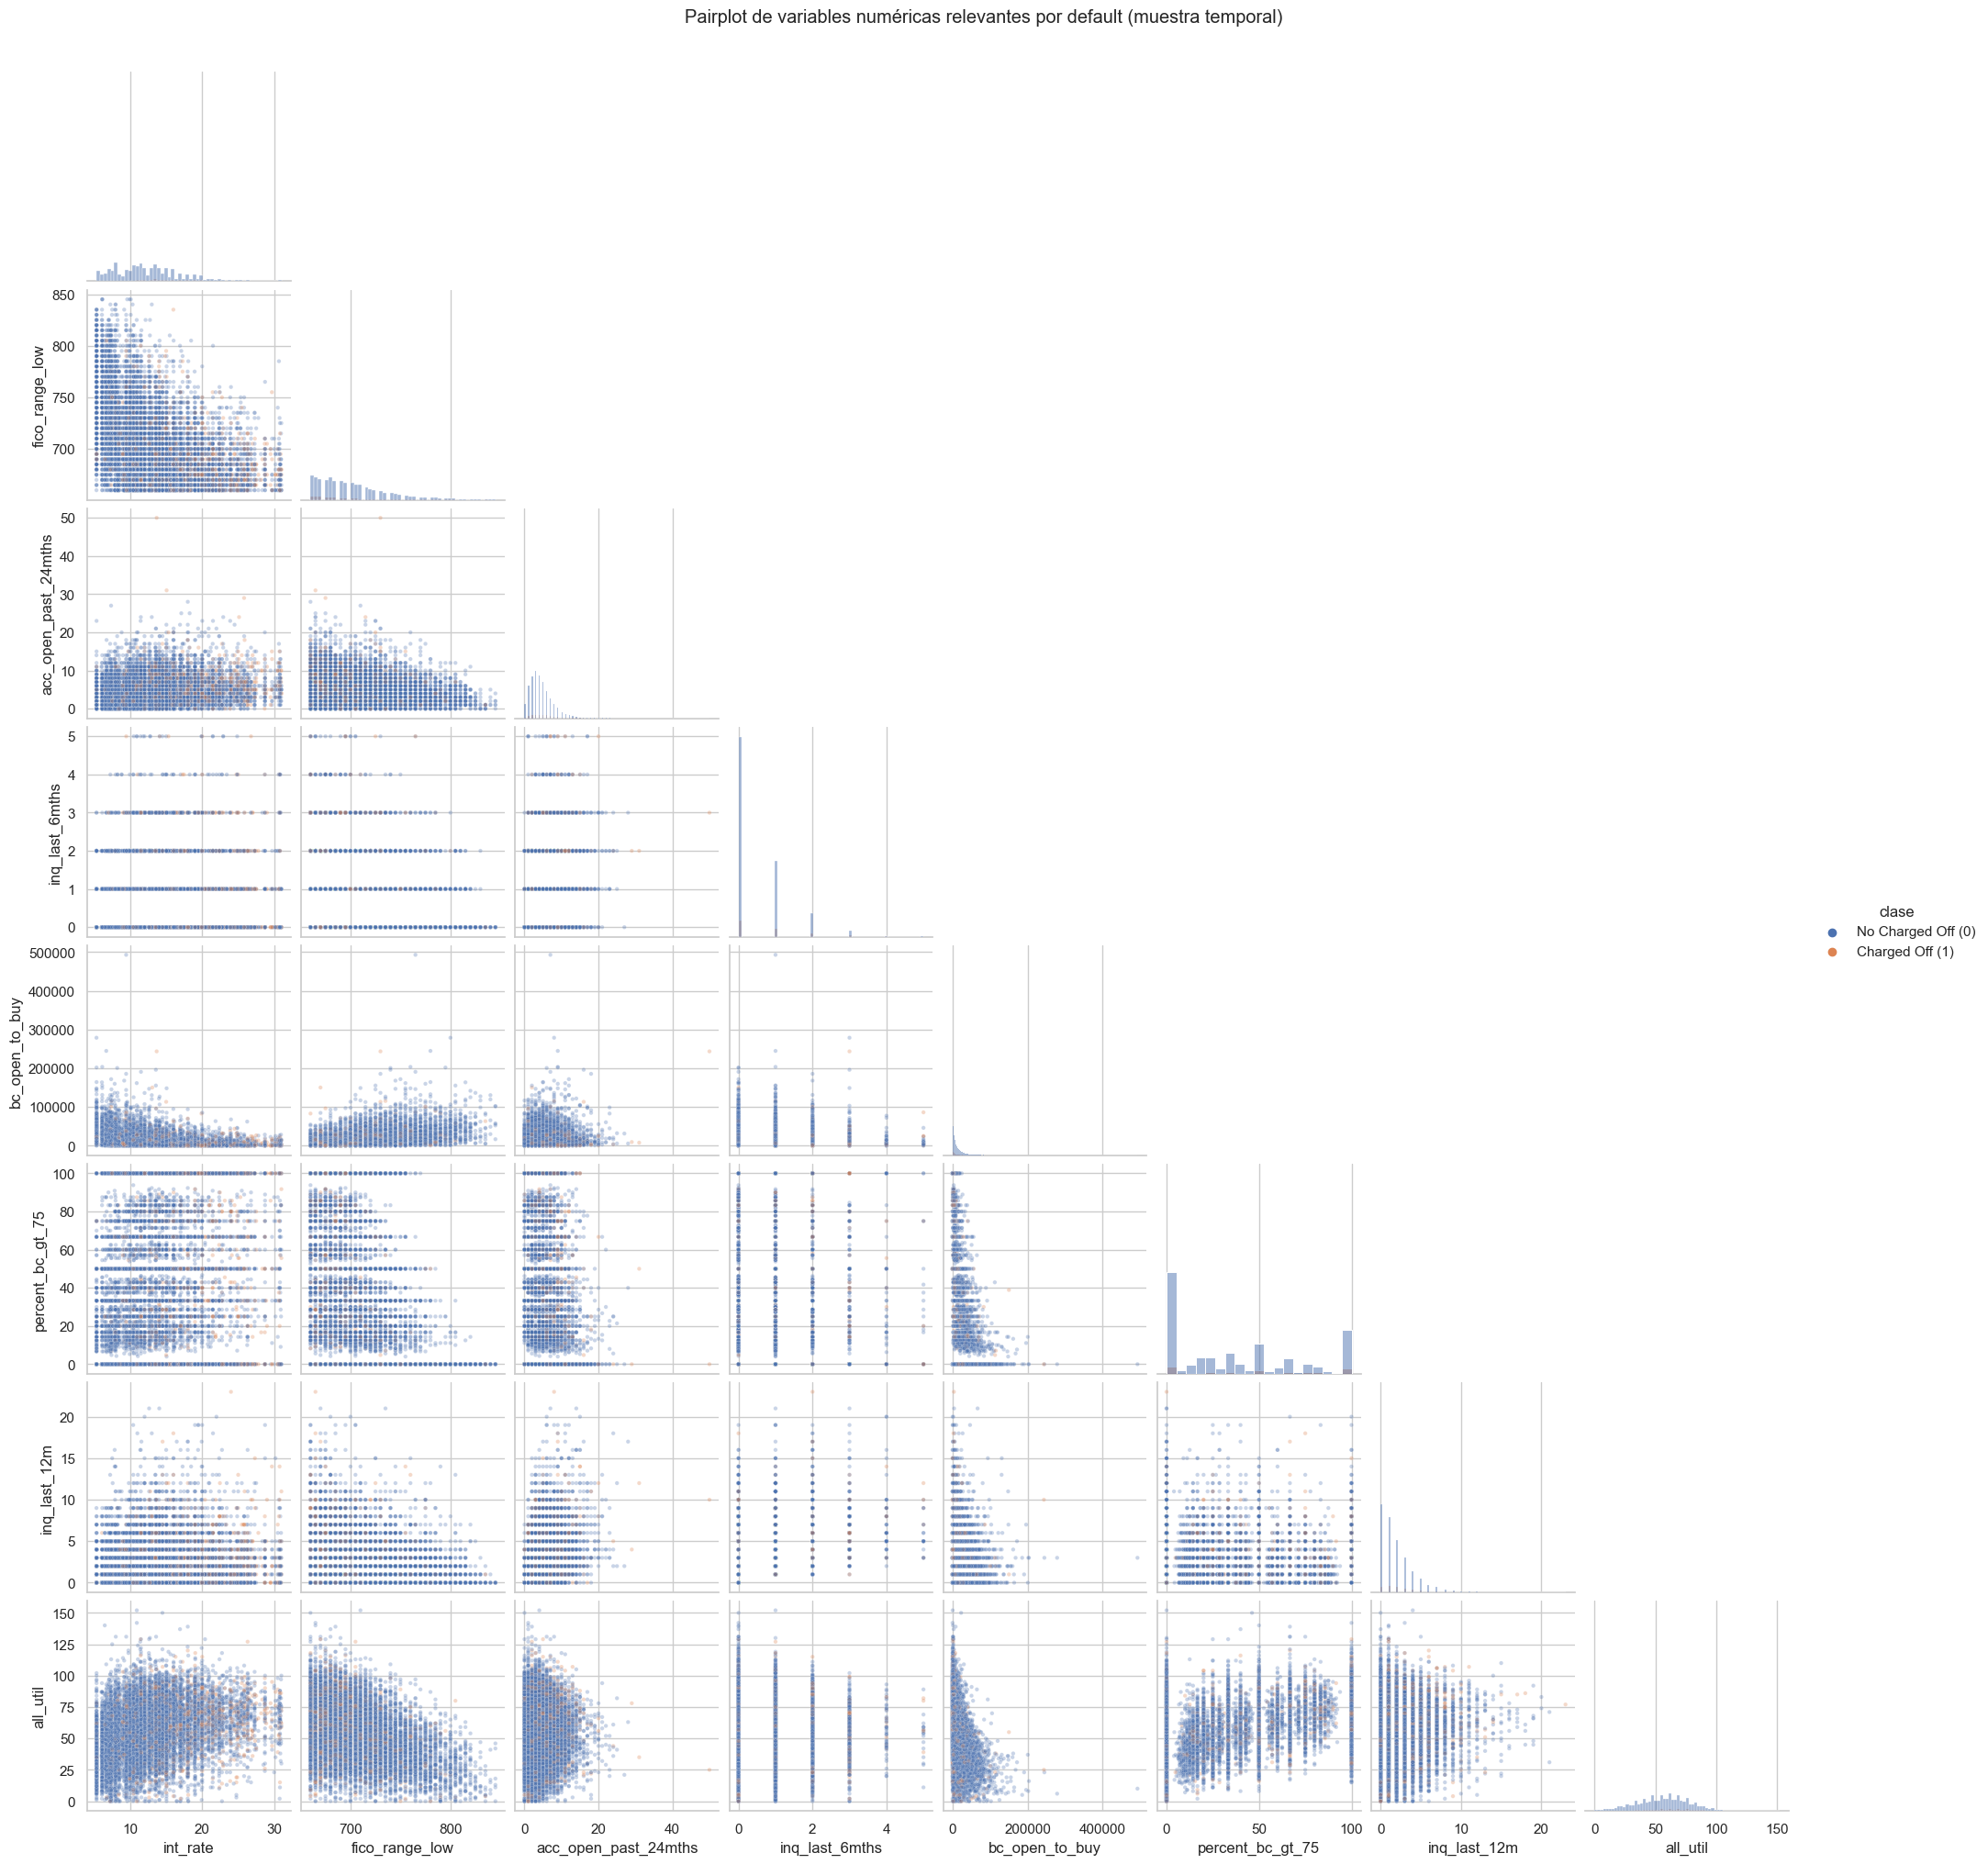

Verificación: df sigue con 2,260,701 filas; la muestra temporal ya fue descartada.


In [30]:
# Visualizaciones avanzadas (2/2): scatter matrix y pairplot. Ambos son costosos de dibujar con millones
# de puntos, así que aquí SÍ se usa una muestra (PAIRPLOT_SAMPLE_SIZE filas) — pero solo para el dibujo:
# 'df' (el dataset completo) no se modifica, y se verifica al final que sigue teniendo el mismo tamaño.
PAIRPLOT_SAMPLE_SIZE = 15_000

rows_before = len(df)
tmp = df[top_numericas_viz + ["default"]].dropna()
# La muestra se utiliza exclusivamente para visualización. Los cálculos estadísticos y el modelado utilizan el dataset completo.
tmp = tmp.sample(n=min(PAIRPLOT_SAMPLE_SIZE, len(tmp)), random_state=RANDOM_STATE)
tmp["clase"] = tmp["default"].map(CLASS_LABELS)

# --- Scatter matrix (máximo 5 variables, para que la matriz siga siendo legible) ---
# Matriz de dispersión: cada celda fuera de la diagonal es un scatter entre dos variables, coloreado por clase;
# la diagonal muestra un histograma de cada variable.
scatter_vars = top_numericas_viz[:5]
axarr = pd.plotting.scatter_matrix(tmp[scatter_vars], c=tmp["default"].map({0: "#2E86AB", 1: "#D1495B"}),
                                   figsize=(2.4 * len(scatter_vars), 2.4 * len(scatter_vars)),
                                   diagonal="hist", alpha=0.35, s=8)
plt.suptitle("Scatter matrix (muestra temporal, no afecta a df)", y=1.02)
plt.show()

# --- Pairplot (todas las numéricas del top 10) ---
# Similar al scatter matrix pero de seaborn: además separa por color ('hue') según la clase y permite
# 'corner=True' para no repetir cada par de variables dos veces (arriba y abajo de la diagonal).
sns.pairplot(tmp, vars=top_numericas_viz, hue="clase", corner=True, diag_kind="hist",
            plot_kws=dict(alpha=0.3, s=10))
plt.suptitle("Pairplot de variables numéricas relevantes por default (muestra temporal)", y=1.02)
plt.show()

del tmp   # se descarta la muestra temporal explícitamente, ya cumplió su único propósito (graficar)
assert len(df) == rows_before, "El DataFrame principal no debe cambiar de tamaño."
print(f"Verificación: df sigue con {len(df):,} filas; la muestra temporal ya fue descartada.")

### 4. Scatter matrix y 5. Pairplot

Ninguna combinación de dos variables muestra una separación limpia entre clases: el traslape es sustancial en todas las vistas bivariadas, consistente con que ninguna asociación individual con `default` supera 0.23 (sección de selección de variables). Esto indica que el riesgo de impago no se explica por una sola variable ni por la interacción simple de dos de ellas.

### Implicaciones para el modelado

Dado que ninguna variable (ni par de variables) separa las clases por sí sola, el poder predictivo del modelo dependerá de **combinar** las 10 variables y de que el algoritmo pueda capturar relaciones no necesariamente lineales entre ellas lo que favorece el uso de modelos de árboles/ensamble (Random Forest, Gradient Boosting) además de la regresión logística de referencia, y refuerza que la evaluación se apoye en ROC-AUC/AUC-PR y no en accuracy simple, dado el desbalance de clases. Adicionalmente, la asimetría marcada y las colas largas observadas en `bc_open_to_buy`, `inq_last_6mths`/`inq_last_12m` y `acc_open_past_24mths`. Se confirman visualmente en el boxplot y el KDE, y se tendrán en cuenta especialmente para los modelos lineales (regresión logística, SVM), que son más sensibles a la forma de la distribución que los modelos basados en árboles.

In [31]:
# ¿Faltan en las mismas filas?
m1 = df["inq_last_12m"].isna()
m2 = df["all_util"].isna()

tabla_conjunta = pd.crosstab(m1, m2, rownames=["falta_inq_last_12m"], colnames=["falta_all_util"])
print("Tabla de coincidencia de faltantes:")
display(tabla_conjunta)

solapamiento = (m1 & m2).sum()
print(f"Filas donde faltan AMBAS: {solapamiento:,} "
      f"({100*solapamiento/len(df):.2f}% del dataset)")
print(f"Faltan en inq_last_12m pero no en all_util: {(m1 & ~m2).sum():,}")
print(f"Faltan en all_util pero no en inq_last_12m: {(~m1 & m2).sum():,}")

# ¿Ese patrón de faltante está asociado con default? (mismo criterio que missing_assoc del EDA)
for col, m in [("inq_last_12m", m1), ("all_util", m2)]:
    tasa_falta = df.loc[m, "default"].mean()
    tasa_presente = df.loc[~m, "default"].mean()
    tabla_2x2 = pd.crosstab(m, df["default"])
    chi2, p, _, _ = stats.chi2_contingency(tabla_2x2)
    print(f"\n{col}: tasa default si falta = {100*tasa_falta:.2f}% | "
          f"tasa default si presente = {100*tasa_presente:.2f}% | "
          f"diferencia = {100*(tasa_falta - tasa_presente):+.2f} pp | p={p:.2e}")

Tabla de coincidencia de faltantes:


falta_all_util,False,True
falta_inq_last_12m,,
False,1394319,219
True,1,866162


Filas donde faltan AMBAS: 866,162 (38.31% del dataset)
Faltan en inq_last_12m pero no en all_util: 1
Faltan en all_util pero no en inq_last_12m: 219

inq_last_12m: tasa default si falta = 17.14% | tasa default si presente = 8.61% | diferencia = +8.53 pp | p=0.00e+00

all_util: tasa default si falta = 17.14% | tasa default si presente = 8.61% | diferencia = +8.52 pp | p=0.00e+00


#### Síntesis final

In [32]:
# 9.10.4.1.5 (parte 3) — Síntesis final del EDA: recopila las cifras clave calculadas en todo el
# notebook (calidad de datos, variables prometedoras, problemas detectados) y las imprime como un
# resumen ejecutivo legible, listo para copiar en el informe.
tasa_default_global = 100 * df["default"].mean()
n_eliminar = int((missing_summary["pct_missing"] > 70).sum())
n_imputar_avanzado = int(((missing_summary["pct_missing"] > 30) & (missing_summary["pct_missing"] <= 70)).sum())
n_imputar_simple = int(((missing_summary["pct_missing"] > 0) & (missing_summary["pct_missing"] <= 30)).sum())
outliers_altos = numeric_summary[numeric_summary["outliers_IQR_pct"] > 5].index.tolist()

print("=== RESUMEN EJECUTIVO DEL EDA ===\n")

print("1. CALIDAD DE LOS DATOS")
print(f"- Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas.")
print(f"- {n_eliminar} columnas con >70% de faltantes (candidatas a eliminación).")
print(f"- {n_imputar_avanzado} columnas entre 30% y 70% de faltantes (evaluar imputación avanzada).")
print(f"- {n_imputar_simple} columnas con <30% de faltantes (imputación simple).")
print(f"- {len(columnas_leakage)} columnas marcadas como posible leakage (información posterior a la originación).")
print(f"- id y member_id excluidas del análisis por ser identificadores sin valor predictivo.")
print(f"- Target: se sigue literalmente la regla del enunciado (1 = Charged Off, 0 = No Charged Off). La clase 0 "
      f"incluye Fully Paid, Current, Late, In Grace Period, etc.; no se elimina ningún estado.\n")

print("2. VARIABLES MÁS PROMETEDORAS PARA PREDECIR DEFAULT")
for _, row in seleccion_final.iterrows():
    print(f"   - {row['variable']} ({row['tipo']}): {row['metrica']} = {row['valor_metrica']:.3f}, p={row['p_value']:.2e}")
print()

print("3. PROBLEMAS DETECTADOS")
tasa_min = min(tasa_default_global, 100 - tasa_default_global)
print(f"- Desbalance de clases: {tasa_default_global:.2f}% Charged Off vs {100 - tasa_default_global:.2f}% No Charged Off "
      f"({'desbalance relevante' if tasa_min < 20 else 'desbalance moderado'}).")
print(f"- {len(pares_alta_corr_df)} pares numéricos con |Pearson r| > {CORR_THRESHOLD} (multicolinealidad).")
print(f"- {len(pares_alta_asociacion_cat_df)} pares categóricos con V de Cramér > {CORR_THRESHOLD}.")
print(f"- {len(outliers_altos)} variables numéricas con más de 5% de outliers según IQR.")
print(f"- {int(missing_assoc['asociacion_relevante'].sum())} variables cuyo indicador de faltante se asocia con default "
      f"(|diferencia| >= {UMBRAL_DIF_MISSING} y p < 0.05; diagnóstico descriptivo, no prueba formal de MCAR).\n")

print("4. DECISIONES PRELIMINARES PARA EL PREPROCESAMIENTO")
print(f"- Variables candidatas principales: {', '.join(seleccion_final['variable'].tolist())}.")
print("- Excluir permanentemente: id, member_id, loan_status, las columnas de leakage y las categóricas de")
print("  cardinalidad extrema (identificadores, texto libre).")
print("- Evaluar transformación log/Box-Cox en variables numéricas con |skew| > 1.")
print("- Aplicar estratificación por default en la partición train/test dado el desbalance observado.")
print("- Definir imputación por variable según la tabla de la sección 9.10.4.1.4 (mediana / moda / 'Missing' / eliminar).")
print("- emp_length se usa en el modelado como numérica (emp_length_num: '< 1 year' -> 0.5, '10+ years' -> 10).")

# Tabla final que junta la selección de variables con su % de faltantes, para tenerlo todo en un solo lugar.
resumen_ejecutivo_df = seleccion_final.merge(
    missing_summary[["variable", "pct_missing"]], on="variable", how="left")
display(resumen_ejecutivo_df)

=== RESUMEN EJECUTIVO DEL EDA ===

1. CALIDAD DE LOS DATOS
- Dataset: 2,260,701 filas x 153 columnas.
- 40 columnas con >70% de faltantes (candidatas a eliminación).
- 17 columnas entre 30% y 70% de faltantes (evaluar imputación avanzada).
- 93 columnas con <30% de faltantes (imputación simple).
- 36 columnas marcadas como posible leakage (información posterior a la originación).
- id y member_id excluidas del análisis por ser identificadores sin valor predictivo.
- Target: se sigue literalmente la regla del enunciado (1 = Charged Off, 0 = No Charged Off). La clase 0 incluye Fully Paid, Current, Late, In Grace Period, etc.; no se elimina ningún estado.

2. VARIABLES MÁS PROMETEDORAS PARA PREDECIR DEFAULT
   - sub_grade (categórica): V de Cramér = 0.227, p=0.00e+00
   - int_rate (numérica): |correlación punto-biserial| = 0.199, p=0.00e+00
   - fico_range_low (numérica): |correlación punto-biserial| = 0.119, p=0.00e+00
   - verification_status (categórica): V de Cramér = 0.095, p=0.00e+0

,variable,tipo,metrica,valor_metrica,p_value,pct_missing
0,sub_grade,categórica,V de Cramér,0.227241,0.0,0.001460
1,int_rate,numérica,|correlación punto-biserial|,0.198918,0.0,0.001460
2,fico_range_low,numérica,|correlación punto-biserial|,0.119437,0.0,0.001460
3,verification_status,categórica,V de Cramér,0.094978,0.0,0.001460
4,acc_open_past_24mths,numérica,|correlación punto-biserial|,0.093171,0.0,2.214490
5,inq_last_6mths,numérica,|correlación punto-biserial|,0.083363,0.0,0.002787
6,bc_open_to_buy,numérica,|correlación punto-biserial|,0.082013,0.0,3.316140
7,percent_bc_gt_75,numérica,|correlación punto-biserial|,0.076392,0.0,3.335779
8,inq_last_12m,numérica,|correlación punto-biserial|,0.071265,0.0,38.313912
9,all_util,numérica,|correlación punto-biserial|,0.067825,0.0,38.323555


#### Interpretación del resumen ejecutivo


El dataset final cuenta con 2.260.701 filas y 153 columnas, un volumen grande que exige trabajar con toda la muestra (sin sampling) para no perder representatividad, tal como establece el enunciado. El desbalance de clases es marcado: solo 11.88% de los préstamos terminan en Charged Off frente a 88.12% que no, lo que descarta usar accuracy como métrica de evaluación y obliga a estratificar la partición train/test y a apoyarse en ROC-AUC, AUC-PR, precision y recall de la clase minoritaria durante el modelado.

De las 153 columnas originales, 36 se identificaron como posible *data leakage* (información posterior a la originación del préstamo) y se excluyeron por completo, junto con `id`, `member_id`, `loan_status` y las categóricas de cardinalidad extrema. En cuanto a faltantes, 40 columnas superan el 70% (candidatas a eliminación) y 17 caen en el rango 30%-70% (requieren imputación avanzada o indicador de faltante); de estas últimas, dos entraron al top 10 de variables prometedoras (`inq_last_12m` y `all_util`, ~38% de faltantes cada una) precisamente porque su patrón de faltante resultó fuertemente informativo sobre `default` — hallazgo que también refleja el resultado más amplio de que 97 variables del dataset muestran un indicador de missingness asociado al target, así que el tratamiento de faltantes no es un detalle secundario en este dataset, sino parte del poder predictivo.

La multicolinealidad es alta a nivel global (76 pares numéricos con |Pearson r|>0.7 y 70 pares categóricos con V de Cramér>0.7), lo que confirma que reducir a un conjunto pequeño y no redundante de variables —como se hizo con el filtro iterativo de redundancia— es necesario antes de modelar, más allá de dejarlo a criterio del algoritmo. Las 10 variables que sobrevivieron todos los filtros (`sub_grade`, `int_rate`, `fico_range_low`, `verification_status`, `acc_open_past_24mths`, `inq_last_6mths`, `bc_open_to_buy`, `percent_bc_gt_75`, `inq_last_12m`, `all_util`) tienen asociaciones individuales modestas con el target (entre 0.068 y 0.227), lo cual es esperable en riesgo crediticio: ninguna variable aislada explica el impago, y el valor del modelo estará en combinar estas 10 señales —relacionadas con el perfil crediticio (grado, tasa, score) y la actividad crediticia reciente del solicitante— más que en depender de un único predictor dominante. Finalmente, 34 variables numéricas muestran más de 5% de outliers según IQR, que se documentan pero no se eliminan (se conservan como parte de la variabilidad real del riesgo crediticio), reservando la transformación log/Box-Cox solo para las que además muestran asimetría alta (`|skew|>1`).